# Anexo de codigo del TFG

Este notebook reproduce el flujo experimental completo. La
justificacion teorica esta en los caps. 3 y 4 del TFG, la discusion
de resultados en el cap. 5 y las conclusiones en el cap. 6; aqui se
prioriza la operativa de codigo. El notebook se organiza en tres
bloques: carga y exploracion de datos, prediccion de retornos
diarios (cinco modelos sobre acciones y BTC con dos pruebas de
robustez) y prediccion de Bitcoin a 4h, 1h y 15m.

Las salidas (CSV de metricas y figuras PNG) se guardan en
`Resultados/` y `Figuras/`.

## 1. Carga y exploracion de datos

Lectura de las cuatro acciones del S&P 500 desde `yfinance` (precios
ajustados) y de las cuatro temporalidades de Bitcoin desde los CSV
de Binance ya descargados.

### 1.1 Librerias y estilo grafico

Imports, semillas y formato numerico comun para el notebook.

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})
sns.set_palette('tab10')
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'pandas   {pd.__version__}')
print(f'numpy    {np.__version__}')
print(f'yfinance {yf.__version__}')

pandas   3.0.1
numpy    2.4.4
yfinance 1.2.0


### 1.2 Rutas del proyecto

Defino `BASE_DIR` con la raiz del proyecto y, a partir de ella, las
subcarpetas `Datos/`, `Resultados/` y `Figuras/`.

In [ ]:
from pathlib import Path

# Directorio raíz del proyecto.
BASE_DIR = Path(r'C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG')

DIR_DATOS   = BASE_DIR / 'Datos'
DIR_STOCKS  = DIR_DATOS / 'Stocks'
DIR_BTC     = DIR_DATOS / 'BTC'
RESULTS_DIR = BASE_DIR / 'Resultados'
FIGURES_DIR = BASE_DIR / 'Figuras'

DIR_STOCKS.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Raíz del proyecto:', BASE_DIR)

Raíz del proyecto: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG


### 1.3 Descarga de las acciones del S&P 500

Descarga de AAPL, JPM, JNJ y XOM entre 2015 y 2026 con `yfinance`
(precios ajustados por splits y dividendos). La eleccion sectorial
se motiva en el cap. 4 del TFG.

In [4]:
TICKERS    = ['AAPL', 'JPM', 'JNJ', 'XOM']
START_DATE = '2015-01-01'
END_DATE   = '2026-03-15'

print(f'Descargando {TICKERS} ({START_DATE} -> {END_DATE})...')
raw_yf = yf.download(tickers=TICKERS, start=START_DATE,
                     end=END_DATE, auto_adjust=True, progress=False)
print(f'Descarga completada. Shape: {raw_yf.shape}')

Descargando ['AAPL', 'JPM', 'JNJ', 'XOM'] (2015-01-01 -> 2026-03-15)...
Descarga completada. Shape: (2815, 20)


In [5]:
stocks = {}
for ticker in TICKERS:
    df = raw_yf.xs(ticker, axis=1, level=1).copy()
    df.index = pd.to_datetime(df.index)
    df.index.name = 'Date'
    df.columns = df.columns.str.lower()
    df.sort_index(inplace=True)
    df.dropna(subset=['close'], inplace=True)
    stocks[ticker] = df
    print(f'{ticker}: {len(df):,} sesiones  |  '
          f'{df.index.min().date()} -> {df.index.max().date()}')

# Persistencia en CSV para evitar nuevas descargas.
for ticker, df in stocks.items():
    out = DIR_STOCKS / f'{ticker}_2015_2026.csv'
    df.to_csv(out)

AAPL: 2,815 sesiones  |  2015-01-02 -> 2026-03-13
JPM: 2,815 sesiones  |  2015-01-02 -> 2026-03-13
JNJ: 2,815 sesiones  |  2015-01-02 -> 2026-03-13
XOM: 2,815 sesiones  |  2015-01-02 -> 2026-03-13


### 1.4 Carga de Bitcoin en cuatro temporalidades

Lectura de los cuatro CSV de Binance (1d, 4h, 1h y 15m), alineacion
en UTC y normalizacion de los nombres de columnas para que se
puedan procesar con el mismo pipeline que las acciones.

In [6]:
BTC_FILES = {
    '1d' : 'btc_1d_data_2018_to_2025.csv',
    '4h' : 'btc_4h_data_2018_to_2025.csv',
    '1h' : 'btc_1h_data_2018_to_2025.csv',
    '15m': 'btc_15m_data_2018_to_2025.csv',
}

btc = {}
for tf, fname in BTC_FILES.items():
    df = pd.read_csv(DIR_BTC / fname)
    df.columns = (df.columns.str.strip().str.lower()
                    .str.replace(' ', '_'))
    time_col = [c for c in df.columns
                if 'open' in c and 'time' in c]
    if time_col:
        df.rename(columns={time_col[0]: 'open_time'},
                  inplace=True)
    df['open_time'] = pd.to_datetime(df['open_time'], utc=True,
                                     errors='coerce')
    df.set_index('open_time', inplace=True)
    df.index.name = 'Date'
    ohlcv = [c for c in ['open','high','low','close','volume']
             if c in df.columns]
    df = df[ohlcv].apply(pd.to_numeric, errors='coerce')
    df.sort_index(inplace=True)
    df.dropna(subset=['close'], inplace=True)
    btc[tf] = df
    print(f'BTC {tf:>3s}:  {len(df):>8,} filas  |  '
          f'{df.index.min().strftime("%Y-%m-%d")} -> '
          f'{df.index.max().strftime("%Y-%m-%d")}')

BTC  1d:     2,997 filas  |  2018-01-01 -> 2026-03-16
BTC  4h:    17,961 filas  |  2018-01-01 -> 2026-03-15
BTC  1h:    71,783 filas  |  2018-01-01 -> 2026-03-15
BTC 15m:   287,085 filas  |  2018-01-01 -> 2026-03-15


### 1.5 Evolucion de precios

Dos figuras: comparativa de las cuatro acciones (niveles y
rendimiento acumulado base 100 para homogeneizar escalas) y serie
diaria de Bitcoin.

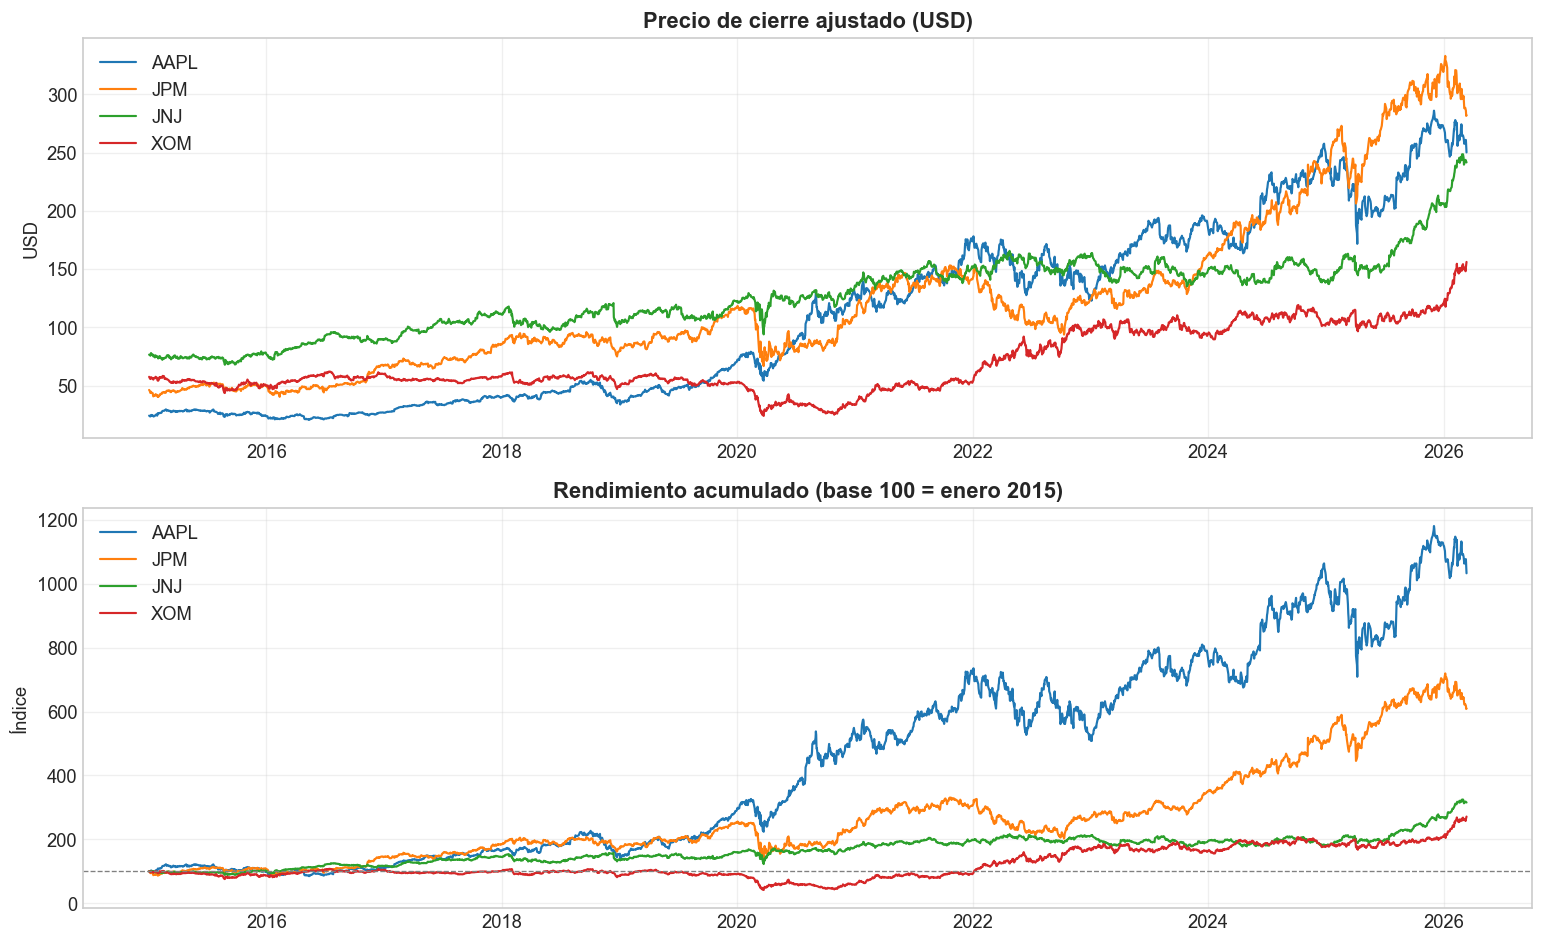

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, (ticker, df) in enumerate(stocks.items()):
    ax1.plot(df.index, df['close'], label=ticker,
             linewidth=1.3, color=colors[i])
ax1.set_title('Precio de cierre ajustado (USD)',
              fontweight='bold')
ax1.set_ylabel('USD')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for i, (ticker, df) in enumerate(stocks.items()):
    base = df['close'].iloc[0]
    ax2.plot(df.index, df['close'] / base * 100, label=ticker,
             linewidth=1.3, color=colors[i])
ax2.axhline(100, color='grey', linestyle='--', linewidth=0.8)
ax2.set_title('Rendimiento acumulado (base 100 = enero 2015)',
              fontweight='bold')
ax2.set_ylabel('Índice')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

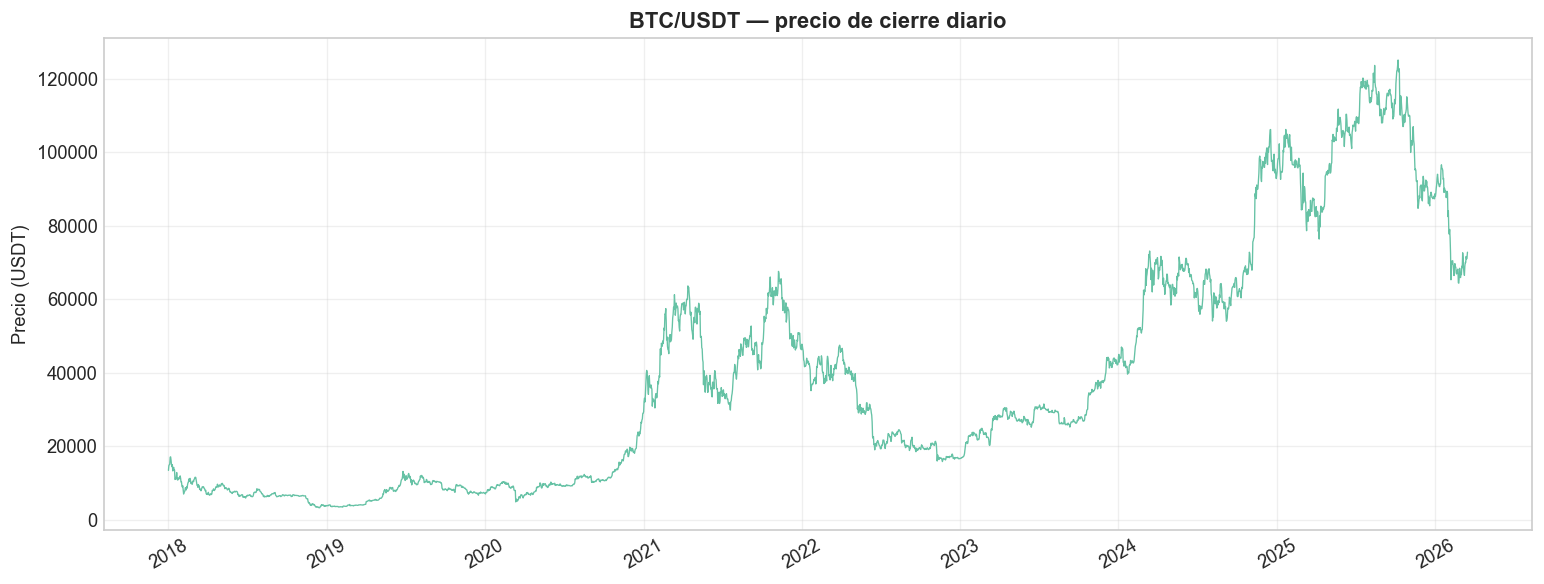

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
df = btc['1d']
color = sns.color_palette('Set2', 1)[0]
ax.plot(df.index, df['close'], linewidth=0.8, color=color)
ax.set_title('BTC/USDT — precio de cierre diario',
             fontweight='bold')
ax.set_ylabel('Precio (USDT)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 1.6 Rendimientos logaritmicos diarios

Calculo de los rendimientos $r_t = \ln(P_t/P_{t-1})$ y de los
estadisticos descriptivos: media, volatilidad, asimetria y exceso de
curtosis.

In [9]:
returns = pd.DataFrame()
for ticker, df in stocks.items():
    returns[ticker] = np.log(df['close'] / df['close'].shift(1))

btc_daily = btc['1d']['close'].copy()
btc_daily.index = btc_daily.index.tz_localize(None)
returns['BTC'] = np.log(btc_daily / btc_daily.shift(1))
returns.dropna(inplace=True)

resumen = pd.DataFrame({
    'Media diaria (%)': returns.mean() * 100,
    'Volatilidad (%)' : returns.std()  * 100,
    'Asimetría'       : returns.skew(),
    'Curtosis exceso' : returns.kurtosis(),
    'Mínimo (%)'      : returns.min()  * 100,
    'Máximo (%)'      : returns.max()  * 100,
}).round(4)
display(resumen)

,Media diaria (%),Volatilidad (%),Asimetría,Curtosis exceso,Mínimo (%),Máximo (%)
AAPL,0.0895,1.9311,-0.0848,6.1726,-13.7708,14.2617
JPM,0.0582,1.8232,-0.0887,12.9196,-16.2106,16.5620
JNJ,0.0377,1.2312,-0.4587,9.3054,-10.5781,7.6940
XOM,0.0484,1.8992,-0.2224,5.4640,-13.0391,11.9442
BTC,0.0710,3.8007,-1.2183,17.2636,-50.2607,17.8449


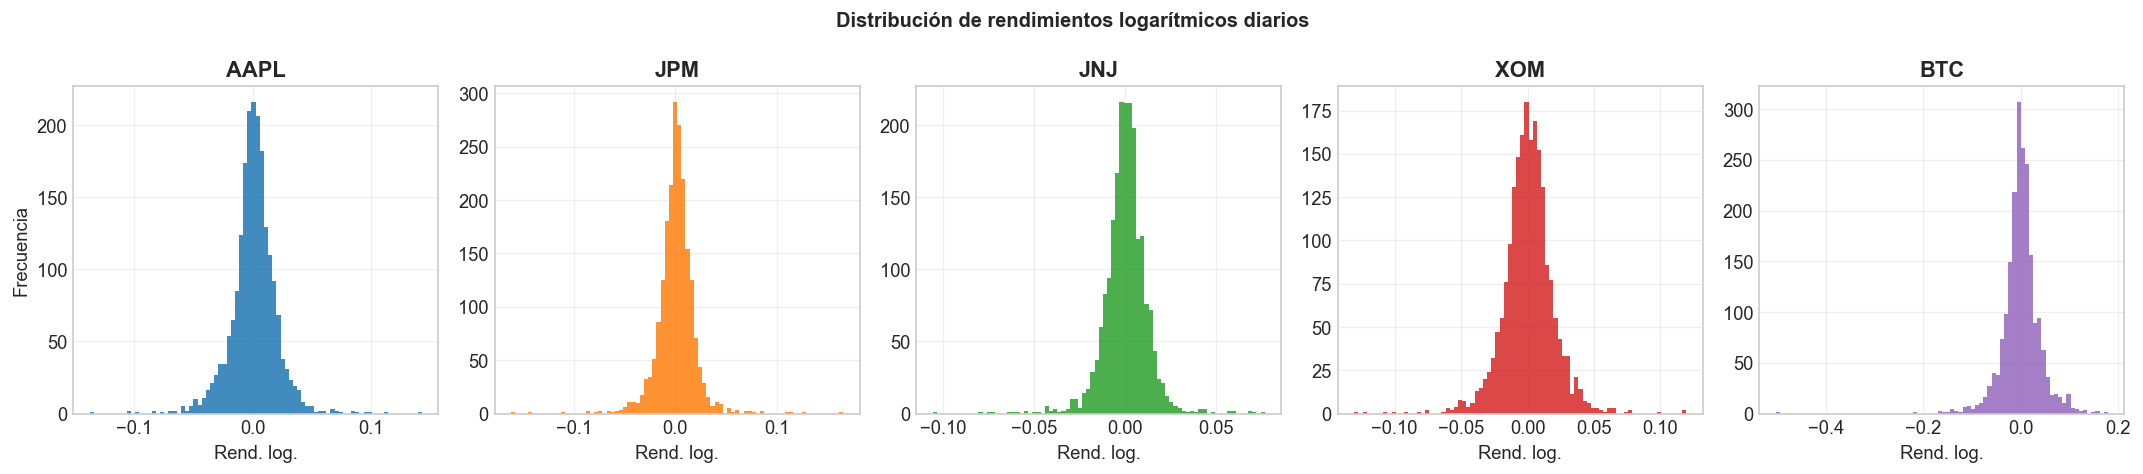

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
pal2 = sns.color_palette('tab10', 5)
for idx, col in enumerate(returns.columns):
    axes[idx].hist(returns[col].dropna(), bins=80,
                   color=pal2[idx], edgecolor='none', alpha=0.85)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_xlabel('Rend. log.')
    if idx == 0:
        axes[idx].set_ylabel('Frecuencia')
plt.suptitle('Distribución de rendimientos logarítmicos diarios',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

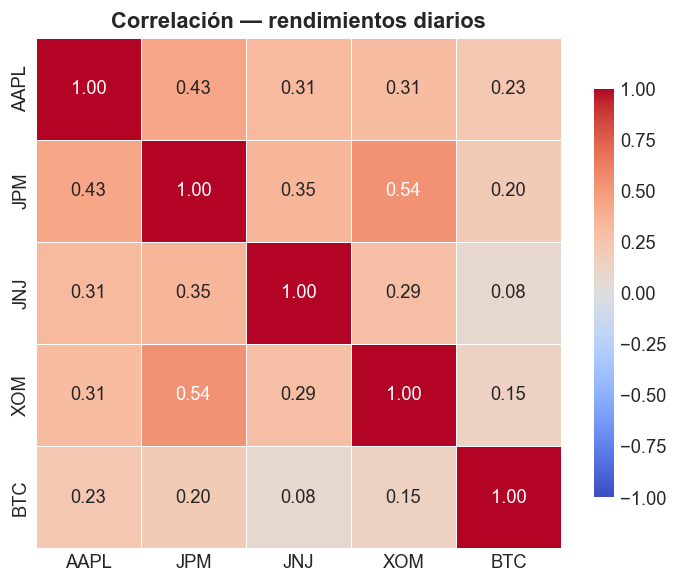

In [11]:
corr = returns.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlación — rendimientos diarios',
             fontweight='bold')
plt.tight_layout()
plt.show()

Las cifras anteriores se discuten en la seccion 5.1 del TFG (colas
pesadas, volatilidad relativa de BTC y correlaciones).

## 2. Prediccion de retornos logaritmicos diarios

Bloque de modelizacion. Cinco modelos (Naive, ARIMA, Random Forest,
XGBoost y LSTM) sobre los cinco activos en dos horizontes, con
walk-forward, intervalos de confianza bootstrap y test de
Diebold-Mariano. Dos pruebas de robustez: perdida de Huber en la
LSTM y correccion del look-ahead bias en el ARIMA a 5d.

| Parametro | Valor |
|---|---|
| Activos | AAPL, JPM, JNJ, XOM, BTC/USDT |
| Periodo | 2015-2026 (acciones) / 2018-2026 (BTC) |
| Splits | Train <= 2022 / Val = 2023 / Test >= 2024 |
| Horizontes | 1 dia, 5 dias |

### 2.1 Imports del pipeline de aprendizaje automatico

Imports especificos del bloque y semillas fijas para
reproducibilidad. La libreria `dieboldmariano` implementa el test
DM (descrito en la seccion 3.8 del TFG); si no esta instalada, las
comparaciones DM se omiten con un aviso.

In [4]:
import itertools
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import (RandomForestRegressor,
                              RandomForestClassifier)
from sklearn.inspection import permutation_importance

import xgboost as xgb

import statsmodels.api as sm
from pmdarima import auto_arima

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

try:
    from dieboldmariano import dm_test
    DM_AVAILABLE = True
except ImportError:
    DM_AVAILABLE = False
    print("Aviso: 'dieboldmariano' no instalado.")

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')
print(f'XGBoost:    {xgb.__version__}')
print(f'DM test:    '
      f'{"disponible" if DM_AVAILABLE else "NO instalado"}')

TensorFlow: 2.21.0
XGBoost:    3.2.0
DM test:    disponible


In [5]:
# Helper de progreso persistente en el notebook
def progress_iter(iterable, desc='', every=100, total=None):
    if total is None:
        try:
            total = len(iterable)
        except TypeError:
            total = None
    for i, x in enumerate(iterable):
        if total is not None:
            last = (i == total - 1)
            if i == 0 or (i + 1) % every == 0 or last:
                pct = 100.0 * (i + 1) / total
                print(f'  {desc}: {i+1}/{total} ({pct:.1f}%)')
        else:
            if (i + 1) % every == 0:
                print(f'  {desc}: {i+1} iter')
        yield x

### 2.2 Constantes del experimento

Fechas de corte de las particiones y constantes del walk-forward:
`RETRAIN_EVERY=60` (reentrenamiento cada 60 pasos) y `SEQ_LEN=10`
(longitud de secuencia para la LSTM).

In [8]:
STOCK_TICKERS = ['AAPL', 'JPM', 'JNJ', 'XOM']
ALL_TICKERS   = STOCK_TICKERS + ['BTC']

TRAIN_END     = '2022-12-31'
VAL_END       = '2023-12-31'

RETRAIN_EVERY = 60
SEQ_LEN       = 10

STOCKS_DIR = BASE_DIR / 'Datos/Stocks'
BTC_DIR    = BASE_DIR / 'Datos/BTC'

### 2.3 Carga local de los datos y del VIX

Lectura de los CSV de acciones y de BTC diario guardados en el
bloque 1. Descarga del VIX desde Yahoo Finance como regresor
exogeno para las acciones; BTC no usa VIX porque el mercado cripto
opera 24/7 y no se alinea con el calendario bursatil.

In [9]:
def load_stock(ticker: str) -> pd.DataFrame:
    path = STOCKS_DIR / f'{ticker}_2015_2026.csv'
    df = pd.read_csv(path, parse_dates=['Date'], index_col='Date')
    df.columns = [c.lower() for c in df.columns]
    df = df.rename(columns={'close':'Close','open':'Open',
                            'high':'High','low':'Low',
                            'volume':'Volume'})
    return df[['Open','High','Low','Close','Volume']].sort_index()


def load_btc(timeframe='1d') -> pd.DataFrame:
    fname = {'1d' :'btc_1d_data_2018_to_2025.csv',
             '4h' :'btc_4h_data_2018_to_2025.csv',
             '1h' :'btc_1h_data_2018_to_2025.csv',
             '15m':'btc_15m_data_2018_to_2025.csv'}
    path = BTC_DIR / fname[timeframe]
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(
        df['Open time'].str.replace(' UTC','', regex=False))
    df = df.set_index('Date').sort_index()
    cols = ['Open','High','Low','Close','Volume']
    return df[cols].astype(float)


raw = {t: load_stock(t) for t in STOCK_TICKERS}
raw['BTC'] = load_btc('1d')
for t in ALL_TICKERS:
    df = raw[t]
    print(f'{t:5s}: {len(df):,} sesiones  |  '
          f'{df.index[0].date()} — {df.index[-1].date()}')

AAPL : 2,815 sesiones  |  2015-01-02 — 2026-03-13
JPM  : 2,815 sesiones  |  2015-01-02 — 2026-03-13
JNJ  : 2,815 sesiones  |  2015-01-02 — 2026-03-13
XOM  : 2,815 sesiones  |  2015-01-02 — 2026-03-13
BTC  : 2,997 sesiones  |  2018-01-01 — 2026-03-16


In [10]:
# Descarga del índice VIX desde Yahoo Finance
print('Descargando datos del índice VIX...')
vix_raw = yf.download('^VIX', start='2014-01-01',
                      end='2026-06-01', progress=False)
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)
vix_raw = vix_raw[['Close']].rename(columns={'Close':'VIX_Close'})
vix_raw.index = pd.to_datetime(vix_raw.index)

vix_raw['VIX_Return_1d'] = vix_raw['VIX_Close'].pct_change()
vix_raw['VIX_SMA_20']    = vix_raw['VIX_Close'].rolling(20).mean()
vix_raw['VIX_vs_SMA20']  = (vix_raw['VIX_Close']
                            / vix_raw['VIX_SMA_20'] - 1)

VIX_FEATURES = ['VIX_Close','VIX_Return_1d',
                'VIX_SMA_20','VIX_vs_SMA20']

print(f'VIX: {len(vix_raw):,} sesiones  |  '
      f'{vix_raw.index[0].date()} — {vix_raw.index[-1].date()}')

Descargando datos del índice VIX...
VIX: 3,093 sesiones  |  2014-01-02 — 2026-04-21


### 2.4 Ingenieria de caracteristicas

Construccion de 31 features para acciones y 27 para BTC: indicadores
tecnicos (medias moviles, MACD, RSI, bandas de Bollinger, ATR),
bloque de regimen de volatilidad (ratios entre ventanas, percentil
y z-score, Garman-Klass, Parkinson) y cuatro features derivadas del
VIX (solo en acciones). Detalle completo en la seccion 4.2 del TFG.

In [11]:
def add_features_v3(df: pd.DataFrame, vix_df=None):
    '''Bloque base + regimen de volatilidad + VIX (opcional).'''
    d = df.copy()

    # ── Bloque 1: indicadores base ─────────────────────────
    d['Return_1d']  = d['Close'].pct_change(1)
    d['Return_5d']  = d['Close'].pct_change(5)
    d['Return_10d'] = d['Close'].pct_change(10)
    d['Return_20d'] = d['Close'].pct_change(20)

    for w in [20, 50, 200]:
        d[f'SMA_{w}'] = d['Close'].rolling(w).mean()
    ema12 = d['Close'].ewm(span=12, adjust=False).mean()
    ema26 = d['Close'].ewm(span=26, adjust=False).mean()

    d['Price_vs_SMA20']  = d['Close'] / d['SMA_20']  - 1
    d['Price_vs_SMA50']  = d['Close'] / d['SMA_50']  - 1
    d['Price_vs_SMA200'] = d['Close'] / d['SMA_200'] - 1

    d['MACD']        = ema12 - ema26
    d['MACD_Signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_Hist']   = d['MACD'] - d['MACD_Signal']

    delta = d['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    d['RSI_14'] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

    bb_mid = d['Close'].rolling(20).mean()
    bb_std = d['Close'].rolling(20).std()
    bb_up  = bb_mid + 2 * bb_std
    bb_lo  = bb_mid - 2 * bb_std
    d['BB_Width']    = (bb_up - bb_lo) / bb_mid
    d['BB_Position'] = (d['Close'] - bb_lo) / (bb_up - bb_lo + 1e-8)

    tr = pd.concat([
        d['High'] - d['Low'],
        (d['High'] - d['Close'].shift(1)).abs(),
        (d['Low']  - d['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    d['ATR_rel'] = tr.ewm(com=13, adjust=False).mean() / d['Close']

    d['Momentum_5']  = d['Close'] - d['Close'].shift(5)
    d['Momentum_10'] = d['Close'] - d['Close'].shift(10)

    d['Vol_20d']   = d['Return_1d'].rolling(20).std()
    d['Vol_rel']   = (d['Volume']
                      / (d['Volume'].rolling(20).mean() + 1e-8))
    d['Day_Range'] = (d['High'] - d['Low']) / d['Close']

    # ── Bloque 2: régimen de volatilidad ───────────────────
    vol5  = d['Return_1d'].rolling(5).std()
    vol10 = d['Return_1d'].rolling(10).std()
    vol60 = d['Return_1d'].rolling(60).std()
    d['Vol_ratio_5_20']  = vol5  / (d['Vol_20d'] + 1e-8)
    d['Vol_ratio_10_60'] = vol10 / (vol60 + 1e-8)

    d['Vol_percentile_60'] = d['Vol_20d'].rolling(60).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)

    vol20_m = d['Vol_20d'].rolling(60).mean()
    vol20_s = d['Vol_20d'].rolling(60).std()
    d['Vol_zscore_60'] = (d['Vol_20d'] - vol20_m) / (vol20_s + 1e-8)

    log_hl = np.log(d['High'] / d['Low'])
    log_co = np.log(d['Close'] / d['Open'])
    gk = 0.5 * log_hl**2 - (2*np.log(2) - 1) * log_co**2
    d['Garman_Klass_vol'] = np.sqrt(gk.rolling(20).mean() * 252)

    d['Parkinson_vol'] = np.sqrt(
        (1 / (4*np.log(2)))
        * (np.log(d['High']/d['Low'])**2).rolling(20).mean() * 252)

    d['Vol_of_vol'] = d['Vol_20d'].rolling(20).std()

    vol_rel_60 = (d['Vol_20d']
                  / (d['Vol_20d'].rolling(60).mean() + 1e-8))
    d['Volume_vol_ratio'] = d['Vol_rel'] / (vol_rel_60 + 1e-8)

    # ── Bloque 3: VIX (solo acciones) ──────────────────────
    if vix_df is not None:
        d = d.join(vix_df[VIX_FEATURES], how='left')
        for col in VIX_FEATURES:
            d[col] = d[col].ffill()

    for c in ['SMA_20','SMA_50','SMA_200']:
        d.drop(columns=[c], errors='ignore', inplace=True)

    return d


FEATURE_COLS_STOCKS = [
    'Return_1d','Return_5d','Return_10d','Return_20d',
    'Price_vs_SMA20','Price_vs_SMA50','Price_vs_SMA200',
    'MACD','MACD_Signal','MACD_Hist','RSI_14',
    'BB_Width','BB_Position','ATR_rel',
    'Momentum_5','Momentum_10','Vol_20d','Vol_rel','Day_Range',
    'Vol_ratio_5_20','Vol_ratio_10_60','Vol_percentile_60',
    'Vol_zscore_60','Garman_Klass_vol','Parkinson_vol',
    'Vol_of_vol','Volume_vol_ratio',
] + VIX_FEATURES

FEATURE_COLS_BTC = [c for c in FEATURE_COLS_STOCKS
                    if c not in VIX_FEATURES]

data = {}
for t in STOCK_TICKERS:
    data[t] = add_features_v3(raw[t], vix_df=vix_raw)
data['BTC'] = add_features_v3(raw['BTC'], vix_df=None)

print(f'Features acciones: {len(FEATURE_COLS_STOCKS)}  |  '
      f'Features BTC: {len(FEATURE_COLS_BTC)}')

Features acciones: 31  |  Features BTC: 27


#### Features semanales para el horizonte de cinco dias

Cinco features con ventana de cinco dias alineadas al horizonte 5d:
retorno acumulado rezagado, volatilidad intrasemanal, momentum, RSI
semanal y volumen relativo. Las features diarias por si solas no
capturan la dinamica intrasemanal.

In [12]:
def add_weekly_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    logret = np.log(d['Close'] / d['Close'].shift(1))
    d['Return_5d_lag1'] = logret.rolling(5).sum().shift(1)
    d['Vol_5d']         = logret.rolling(5).std()
    d['Momentum_5d']    = d['Close'].pct_change(5)
    delta = d['Close'].diff()
    gain  = delta.clip(lower=0).rolling(5).mean()
    loss  = (-delta.clip(upper=0)).rolling(5).mean()
    d['RSI_5d'] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))
    d['Vol_mean_5d'] = (d['Volume'].rolling(5).mean()
                        / (d['Volume'].rolling(20).mean() + 1e-8))
    return d


WEEKLY_FEATURES = ['Return_5d_lag1', 'Vol_5d', 'Momentum_5d',
                   'RSI_5d', 'Vol_mean_5d']
print(f'Features semanales: {WEEKLY_FEATURES}')

Features semanales: ['Return_5d_lag1', 'Vol_5d', 'Momentum_5d', 'RSI_5d', 'Vol_mean_5d']


### 2.5 Preparacion de datasets con particion temporal

Particiones cronologicas estrictas: train hasta 2022-12-31,
validacion en 2023 y test desde 2024-01-01. Construccion de los
targets de regresion (retorno a 1d y retorno acumulado a 5d) y del
target binario para clasificacion ($y=1$ si el retorno a 1d es
positivo).

In [13]:
def prepare_dataset(df: pd.DataFrame, feature_cols: list):
    d = df.copy()
    d['logret']     = np.log(d['Close'] / d['Close'].shift(1))
    d['target_1d']  = d['logret'].shift(-1)
    d['target_5d']  = np.log(d['Close'].shift(-5) / d['Close'])
    d['target_cls'] = (d['target_1d'] > 0).astype(int)

    d = add_weekly_features(d)

    feats_1d = [c for c in feature_cols if c in d.columns]
    feats_5d = feats_1d + [c for c in WEEKLY_FEATURES
                           if c in d.columns]

    all_cols = list(set(feats_5d + ['target_1d','target_5d']))
    d = d.dropna(subset=all_cols)

    train = d.loc[:TRAIN_END]
    val   = d.loc[TRAIN_END:VAL_END].iloc[1:]
    test  = d.loc[VAL_END:].iloc[1:]

    return {
        'X_train_1d': train[feats_1d],
        'X_val_1d'  : val[feats_1d],
        'X_test_1d' : test[feats_1d],
        'X_train_5d': train[feats_5d],
        'X_val_5d'  : val[feats_5d],
        'X_test_5d' : test[feats_5d],
        'y_train_1d': train['target_1d'],
        'y_val_1d'  : val['target_1d'],
        'y_test_1d' : test['target_1d'],
        'y_train_5d': train['target_5d'],
        'y_val_5d'  : val['target_5d'],
        'y_test_5d' : test['target_5d'],
        'y_train_cls': train['target_cls'],
        'y_val_cls'  : val['target_cls'],
        'y_test_cls' : test['target_cls'],
        'logret_full': d['logret'],
        'feature_cols_1d': feats_1d,
        'feature_cols_5d': feats_5d,
    }


datasets = {}
for t in STOCK_TICKERS:
    datasets[t] = prepare_dataset(data[t], FEATURE_COLS_STOCKS)
datasets['BTC'] = prepare_dataset(data['BTC'], FEATURE_COLS_BTC)

print(f"{'Ticker':<8} {'Train':>6} {'Val':>6} {'Test':>6}  "
      f"{'Feat 1d':>8} {'Feat 5d':>8}")
print('-' * 55)
for t in ALL_TICKERS:
    ds = datasets[t]
    print(f"{t:<8} {len(ds['X_train_1d']):>6,} "
          f"{len(ds['X_val_1d']):>6,} "
          f"{len(ds['X_test_1d']):>6,}  "
          f"{len(ds['feature_cols_1d']):>8} "
          f"{len(ds['feature_cols_5d']):>8}")

Ticker    Train    Val   Test   Feat 1d  Feat 5d
-------------------------------------------------------
AAPL      1,732    245    517        31       36
JPM       1,745    231    512        31       36
JNJ       1,750    237    511        31       36
XOM       1,753    237    521        31       36
BTC       1,577    356    774        27       32


### 2.6 Seleccion de caracteristicas en dos fases

Fase 1: importancia por permutacion sobre un XGBoost base, con
umbral estricto (> 0) para Random Forest y relajado (>= -0,001) para
XGBoost y LSTM. Fase 2: forward greedy que anade features de una en
una maximizando la DA en validacion. Justificacion y resultados en
la seccion 4.6 del TFG.

In [14]:
def feature_selection_phase1(ticker, ds, horizon='1d',
                                n_repeats=10):
    feat_key = f'feature_cols_{horizon}'
    X_key = f'X_train_{horizon}'
    V_key = f'X_val_{horizon}'
    y_key = f'y_train_{horizon}'
    yv_key = f'y_val_{horizon}'

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(ds[X_key].values)
    X_val   = scaler.transform(ds[V_key].values)
    y_train = ds[y_key].values
    y_val   = ds[yv_key].values

    model = xgb.XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0)
    model.fit(X_train, y_train)

    result = permutation_importance(
        model, X_val, y_val, n_repeats=n_repeats,
        scoring='neg_mean_squared_error', random_state=42)
    imp_df = pd.DataFrame({
        'feature': ds[feat_key],
        'importance': result.importances_mean,
    }).sort_values('importance', ascending=False)

    selected_rf  = imp_df.loc[imp_df['importance'] > 0.000,
                              'feature'].tolist()
    selected_xgb = imp_df.loc[imp_df['importance'] >= -0.001,
                              'feature'].tolist()

    print(f"  {ticker} ({horizon}): RF {len(selected_rf)}  "
          f"XGB {len(selected_xgb)}")
    return imp_df, selected_rf, selected_xgb


def directional_accuracy(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return 0.0
    return np.mean(
        np.sign(y_pred[mask]) == np.sign(y_true[mask]))


print('=== Fase 1: Importancia permutada ===')
perm_results        = {}
selected_rf_phase1  = {}
selected_xgb_phase1 = {}
for horizon in ['1d', '5d']:
    for t in ALL_TICKERS:
        imp_df, s_rf, s_xgb = feature_selection_phase1(
            t, datasets[t], horizon)
        perm_results[(t, horizon)]        = imp_df
        selected_rf_phase1[(t, horizon)]  = s_rf
        selected_xgb_phase1[(t, horizon)] = s_xgb

=== Fase 1: Importancia permutada ===
  AAPL (1d): RF 8  XGB 31
  JPM (1d): RF 2  XGB 31
  JNJ (1d): RF 13  XGB 31
  XOM (1d): RF 8  XGB 31
  BTC (1d): RF 15  XGB 27
  AAPL (5d): RF 13  XGB 36
  JPM (5d): RF 15  XGB 36
  JNJ (5d): RF 10  XGB 36
  XOM (5d): RF 7  XGB 36
  BTC (5d): RF 14  XGB 32


In [15]:
def feature_selection_phase2(ticker, ds, candidates,
                                horizon='1d',
                                max_features=20, min_features=8):
    feat_key = f'feature_cols_{horizon}'
    X_tr = ds[f'X_train_{horizon}'][candidates].values
    X_vl = ds[f'X_val_{horizon}'][candidates].values
    y_tr = ds[f'y_train_{horizon}'].values
    y_vl = ds[f'y_val_{horizon}'].values

    selected, remaining = [], list(candidates)
    best_da, no_improve = 0.0, 0

    for step in range(min(max_features, len(remaining))):
        best_feat, best_da_step = None, -1
        for feat in remaining:
            trial = selected + [feat]
            idx = [candidates.index(f) for f in trial]
            sc = StandardScaler()
            Xtr = sc.fit_transform(X_tr[:, idx])
            Xvl = sc.transform(X_vl[:, idx])
            m = xgb.XGBRegressor(
                n_estimators=50, max_depth=3, learning_rate=0.01,
                verbosity=0, random_state=42)
            m.fit(Xtr, y_tr)
            da = directional_accuracy(y_vl, m.predict(Xvl))
            if da > best_da_step:
                best_da_step, best_feat = da, feat

        if best_feat is None:
            break
        selected.append(best_feat)
        remaining.remove(best_feat)

        if best_da_step > best_da:
            best_da, no_improve = best_da_step, 0
        else:
            no_improve += 1
            if no_improve >= 5 and len(selected) >= min_features:
                break

    if len(selected) < min_features:
        extras = [f for f in candidates if f not in selected]
        for feat in extras:
            selected.append(feat)
            if len(selected) >= min_features:
                break

    print(f"  {ticker} ({horizon}): {len(selected)} features "
          f"(DA val: {best_da:.1%})")
    return selected


print('\n=== Fase 2: Selección forward ===')
selected_features_rf  = {}
selected_features_xgb = {}

for horizon in ['1d', '5d']:
    print(f'\n  --- Horizonte {horizon} ---')
    for t in ALL_TICKERS:
        sel_rf = selected_rf_phase1[(t, horizon)]
        if len(sel_rf) >= 3:
            print(f'  [RF]  ', end='')
            feats_rf = feature_selection_phase2(
                t, datasets[t], sel_rf, horizon,
                min_features=min(8, len(sel_rf)))
        else:
            feats_rf = sel_rf
            print(f'  [RF]   {t} ({horizon}): solo '
                  f'{len(sel_rf)} features, se usan todas')
        selected_features_rf[(t, horizon)] = feats_rf

        sel_xgb = selected_xgb_phase1[(t, horizon)]
        print(f'  [XGB] ', end='')
        feats_xgb = feature_selection_phase2(
            t, datasets[t], sel_xgb, horizon)
        selected_features_xgb[(t, horizon)] = feats_xgb

print('\nFeature selection completa')


=== Fase 2: Selección forward ===

  --- Horizonte 1d ---
  [RF]    AAPL (1d): 8 features (DA val: 58.2%)
  [XGB]   AAPL (1d): 8 features (DA val: 58.2%)
  [RF]   JPM (1d): solo 2 features, se usan todas
  [XGB]   JPM (1d): 8 features (DA val: 57.6%)
  [RF]    JNJ (1d): 8 features (DA val: 50.2%)
  [XGB]   JNJ (1d): 13 features (DA val: 51.5%)
  [RF]    XOM (1d): 8 features (DA val: 54.9%)
  [XGB]   XOM (1d): 8 features (DA val: 58.2%)
  [RF]    BTC (1d): 12 features (DA val: 57.6%)
  [XGB]   BTC (1d): 16 features (DA val: 56.2%)

  --- Horizonte 5d ---
  [RF]    AAPL (5d): 11 features (DA val: 65.7%)
  [XGB]   AAPL (5d): 13 features (DA val: 67.3%)
  [RF]    JPM (5d): 8 features (DA val: 60.6%)
  [XGB]   JPM (5d): 8 features (DA val: 61.0%)
  [RF]    JNJ (5d): 8 features (DA val: 44.3%)
  [XGB]   JNJ (5d): 8 features (DA val: 47.7%)
  [RF]    XOM (5d): 7 features (DA val: 56.5%)
  [XGB]   XOM (5d): 9 features (DA val: 57.8%)
  [RF]    BTC (5d): 13 features (DA val: 58.7%)
  [XGB]   B

### 2.7 Evaluacion con intervalos de confianza bootstrap

Bootstrap no parametrico con 1.000 replicas: se remuestrea con
reposicion el par $(y_{\text{real}}, y_{\text{pred}})$ y se
recalcula la metrica. Los percentiles 2,5 y 97,5 dan el IC del 95 %.

In [16]:
def bootstrap_ci(y_true, y_pred, metric_fn,
                   n_boot=1000, ci=0.95):
    rng = np.random.default_rng(42)
    n   = len(y_true)
    vals = [metric_fn(y_true[idx], y_pred[idx])
            for idx in (rng.integers(0, n, n)
                        for _ in range(n_boot))]
    alpha = 1 - ci
    return (np.percentile(vals, 100*alpha/2),
            np.percentile(vals, 100*(1-alpha/2)))


def evaluate_regression(y_true, y_pred, model_name, ticker,
                          horizon='1d'):
    yt = np.asarray(y_true, float)
    yp = np.asarray(y_pred, float)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae  = mean_absolute_error(yt, yp)
    r2   = r2_score(yt, yp)
    da   = directional_accuracy(yt, yp)

    rmse_ci = bootstrap_ci(
        yt, yp,
        lambda a, b: np.sqrt(mean_squared_error(a, b)))
    da_ci = bootstrap_ci(yt, yp, directional_accuracy)

    result = {
        'Model': model_name, 'Ticker': ticker,
        'Horizon': horizon,
        'RMSE': rmse, 'RMSE_CI_low': rmse_ci[0],
        'RMSE_CI_high': rmse_ci[1],
        'MAE': mae, 'R2': r2,
        'DA': da, 'DA_CI_low': da_ci[0],
        'DA_CI_high': da_ci[1]}

    print(f"{ticker:5s} {model_name:15s} {horizon:3s}  "
          f"RMSE: {rmse:.6f} "
          f"[{rmse_ci[0]:.6f}, {rmse_ci[1]:.6f}]  "
          f"DA: {da:.3f} [{da_ci[0]:.3f}, {da_ci[1]:.3f}]")
    return result


def evaluate_classification(y_true, y_pred, model_name, ticker):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    result = {'Model': model_name, 'Ticker': ticker,
              'Accuracy': acc, 'Precision': prec,
              'Recall': rec, 'F1': f1}
    print(f"{ticker:5s} {model_name:15s}  "
          f"Acc: {acc:.3f}  Prec: {prec:.3f}  "
          f"Rec: {rec:.3f}  F1: {f1:.3f}")
    return result

### 2.8 Parte A: Regresion de retornos

Ejecucion de los cinco modelos para los dos horizontes con
walk-forward. La descripcion teorica y los hiperparametros estan en
la seccion 4.5 del TFG. A continuacion, una subseccion por modelo con
las decisiones operativas especificas.

#### 2.8.0 Naive

Predice retorno cero ($\hat{r}_{t+h}=0$). No requiere
entrenamiento. Es el baseline frente al que se compara el resto.

In [17]:
all_results_reg = []
all_preds_reg   = {}

for horizon in ['1d', '5d']:
    print(f'\n{"="*80}')
    print(f'  HORIZONTE {horizon}')
    print(f'{"="*80}')
    for t in ALL_TICKERS:
        ds = datasets[t]
        y_test = ds[f'y_test_{horizon}'].values
        y_pred = np.zeros(len(y_test))
        result = evaluate_regression(
            y_test, y_pred, 'Naïve', t, horizon)
        all_results_reg.append(result)
        all_preds_reg[(t, horizon, 'Naïve')] = y_pred


  HORIZONTE 1d
AAPL  Naïve           1d   RMSE: 0.017627 [0.015191, 0.020462]  DA: 0.000 [0.000, 0.000]
JPM   Naïve           1d   RMSE: 0.015759 [0.013780, 0.018048]  DA: 0.000 [0.000, 0.000]
JNJ   Naïve           1d   RMSE: 0.011127 [0.009840, 0.012698]  DA: 0.000 [0.000, 0.000]
XOM   Naïve           1d   RMSE: 0.013985 [0.012869, 0.015179]  DA: 0.000 [0.000, 0.000]
BTC   Naïve           1d   RMSE: 0.025151 [0.023413, 0.026968]  DA: 0.000 [0.000, 0.000]

  HORIZONTE 5d
AAPL  Naïve           5d   RMSE: 0.040859 [0.036810, 0.045451]  DA: 0.000 [0.000, 0.000]
JPM   Naïve           5d   RMSE: 0.034335 [0.031712, 0.037078]  DA: 0.000 [0.000, 0.000]
JNJ   Naïve           5d   RMSE: 0.023902 [0.022206, 0.025547]  DA: 0.000 [0.000, 0.000]
XOM   Naïve           5d   RMSE: 0.032118 [0.029312, 0.034957]  DA: 0.000 [0.000, 0.000]
BTC   Naïve           5d   RMSE: 0.053596 [0.050593, 0.056718]  DA: 0.000 [0.000, 0.000]


#### 2.8.1 ARIMA

Orden $(p,d,q)$ seleccionado con `auto_arima` sobre el train
($d=0$, ya que los retornos log son estacionarios). Reajuste cada
20 pasos; entre reajustes, `model.append()` actualiza el filtro de
Kalman con cada nueva observacion sin reestimar parametros.

In [41]:
def run_arima(ticker, ds, horizon='1d', refit_every=20,  progress_every=100):
    warnings.filterwarnings('ignore')
    y_all = np.concatenate([
        ds[f'y_train_{horizon}'].values,
        ds[f'y_val_{horizon}'].values,
        ds[f'y_test_{horizon}'].values])
    n_pre  = (len(ds[f'y_train_{horizon}'])
              + len(ds[f'y_val_{horizon}']))
    n_test = len(ds[f'y_test_{horizon}'])

    train_ret = y_all[:n_pre]
    auto_model = auto_arima(
        train_ret, start_p=0, start_q=0, max_p=5, max_q=5,
        d=0, seasonal=False, stepwise=True,
        suppress_warnings=True)
    order = auto_model.order
    print(f"  {ticker} ({horizon}): auto_arima -> {order}")

    model = sm.tsa.ARIMA(train_ret, order=order).fit()
    preds = []
    for i in progress_iter(range(n_test),
                           desc=f'  {ticker} ARIMA {horizon}',
                           every=progress_every):
        preds.append(model.forecast(steps=1)[0])
        if (i + 1) % refit_every == 0:
            try:
                model = sm.tsa.ARIMA(
                    y_all[:n_pre+i+1], order=order).fit()
            except Exception:
                pass
        else:
            try:
                model = model.append(
                    [y_all[n_pre+i]], refit=False)
            except Exception:
                pass
    return np.array(preds)


print("Ejecutando ARIMA walk-forward...")
for horizon in ['1d', '5d']:
    for t in ALL_TICKERS:
        ds = datasets[t]
        y_test = ds[f'y_test_{horizon}'].values
        try:
            y_pred = run_arima(t, ds, horizon)
            result = evaluate_regression(
                y_test, y_pred, 'ARIMA', t, horizon)
            all_results_reg.append(result)
            all_preds_reg[(t, horizon, 'ARIMA')] = y_pred
        except Exception as e:
            print(f"  Error en ARIMA {t} {horizon}: {e}")

Ejecutando ARIMA walk-forward...
  AAPL (1d): auto_arima -> (0, 0, 1)
    AAPL ARIMA 1d: 1/517 (0.2%)
    AAPL ARIMA 1d: 100/517 (19.3%)
    AAPL ARIMA 1d: 200/517 (38.7%)
    AAPL ARIMA 1d: 300/517 (58.0%)
    AAPL ARIMA 1d: 400/517 (77.4%)
    AAPL ARIMA 1d: 500/517 (96.7%)
    AAPL ARIMA 1d: 517/517 (100.0%)
AAPL  ARIMA           1d   RMSE: 0.017745 [0.015390, 0.020428]  DA: 0.484 [0.440, 0.524]
  JPM (1d): auto_arima -> (2, 0, 0)
    JPM ARIMA 1d: 1/512 (0.2%)
    JPM ARIMA 1d: 100/512 (19.5%)
    JPM ARIMA 1d: 200/512 (39.1%)
    JPM ARIMA 1d: 300/512 (58.6%)
    JPM ARIMA 1d: 400/512 (78.1%)
    JPM ARIMA 1d: 500/512 (97.7%)
    JPM ARIMA 1d: 512/512 (100.0%)
JPM   ARIMA           1d   RMSE: 0.015815 [0.013783, 0.018226]  DA: 0.544 [0.500, 0.588]
  JNJ (1d): auto_arima -> (2, 0, 0)
    JNJ ARIMA 1d: 1/511 (0.2%)
    JNJ ARIMA 1d: 100/511 (19.6%)
    JNJ ARIMA 1d: 200/511 (39.1%)
    JNJ ARIMA 1d: 300/511 (58.7%)
    JNJ ARIMA 1d: 400/511 (78.3%)
    JNJ ARIMA 1d: 500/511 (97.8%)


#### 2.8.2 Random Forest

Busqueda por `TimeSeriesSplit(5)` sobre un grid de 27 combinaciones
($3^3$: `n_estimators`, `max_depth`, `min_samples_leaf`). Usa las
features seleccionadas con umbral estricto.

In [42]:
def run_rf(ticker, ds, horizon='1d',
           retrain_every=RETRAIN_EVERY, selected_feats=None, 
           progress_every=100):
    feat_key = f'feature_cols_{horizon}'
    all_feats = list(ds[feat_key])
    if selected_feats is not None:
        feat_idx = [all_feats.index(f) for f in selected_feats
                    if f in all_feats]
    else:
        feat_idx = list(range(len(all_feats)))

    X_tr = ds[f'X_train_{horizon}'].values[:, feat_idx]
    X_vl = ds[f'X_val_{horizon}'].values[:, feat_idx]
    X_te = ds[f'X_test_{horizon}'].values[:, feat_idx]
    y_tr = ds[f'y_train_{horizon}'].values
    y_vl = ds[f'y_val_{horizon}'].values
    y_te = ds[f'y_test_{horizon}'].values

    scaler_s = StandardScaler()
    X_search = scaler_s.fit_transform(np.vstack([X_tr, X_vl]))
    y_search = np.concatenate([y_tr, y_vl])
    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = [{'n_estimators': n, 'max_depth': d,
                   'min_samples_split': s}
                  for n in [100, 200, 300]
                  for d in [5, 10, 15]
                  for s in [5, 10, 20]]
    best_score, best_params = np.inf, {}
    print(f"  {ticker} ({horizon}): búsqueda RF "
          f"({len(param_grid)} combs, "
          f"{len(feat_idx)} features)...")
    for params in param_grid:
        scores = []
        for tr_i, vl_i in tscv.split(X_search):
            rf = RandomForestRegressor(
                **params, n_jobs=-1, random_state=42)
            rf.fit(X_search[tr_i], y_search[tr_i])
            scores.append(np.sqrt(mean_squared_error(
                y_search[vl_i], rf.predict(X_search[vl_i]))))
        if np.mean(scores) < best_score:
            best_score, best_params = np.mean(scores), params
    print(f"  {ticker} ({horizon}): mejor = {best_params}")

    X_pool = np.vstack([X_tr, X_vl])
    y_pool = np.concatenate([y_tr, y_vl])
    preds = []
    for i in progress_iter(range(len(y_te)),
                           desc=f'  {ticker} RF {horizon}',
                           every=progress_every):
        if i == 0 or i % retrain_every == 0:
            sc = StandardScaler()
            end = (len(X_pool) - len(y_te) + i
                   if i > 0 else len(X_pool))
            X_fit = sc.fit_transform(X_pool[:end])
            y_fit = y_pool[:end]
            rf = RandomForestRegressor(
                **best_params, n_jobs=-1, random_state=42)
            rf.fit(X_fit, y_fit)
        preds.append(rf.predict(sc.transform(X_te[i:i+1]))[0])
    return np.array(preds)


print('Ejecutando Random Forest walk-forward...')
for horizon in ['1d', '5d']:
    for t in ALL_TICKERS:
        ds = datasets[t]
        y_test = ds[f'y_test_{horizon}'].values
        rf_feats = selected_features_rf.get((t, horizon))
        try:
            y_pred = run_rf(t, ds, horizon,
                             selected_feats=rf_feats)
            result = evaluate_regression(
                y_test, y_pred, 'Random Forest', t, horizon)
            all_results_reg.append(result)
            all_preds_reg[(t, horizon, 'Random Forest')] = y_pred
        except Exception as e:
            print(f'  Error en RF {t} {horizon}: {e}')

Ejecutando Random Forest walk-forward...
  AAPL (1d): búsqueda RF (27 combs, 8 features)...
  AAPL (1d): mejor = {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 20}
    AAPL RF 1d: 1/517 (0.2%)
    AAPL RF 1d: 100/517 (19.3%)
    AAPL RF 1d: 200/517 (38.7%)
    AAPL RF 1d: 300/517 (58.0%)
    AAPL RF 1d: 400/517 (77.4%)
    AAPL RF 1d: 500/517 (96.7%)
    AAPL RF 1d: 517/517 (100.0%)
AAPL  Random Forest   1d   RMSE: 0.017838 [0.015216, 0.020855]  DA: 0.548 [0.507, 0.590]
  JPM (1d): búsqueda RF (27 combs, 2 features)...
  JPM (1d): mejor = {'n_estimators': 300, 'max_depth': 5, 'min_samples_split': 20}
    JPM RF 1d: 1/512 (0.2%)
    JPM RF 1d: 100/512 (19.5%)
    JPM RF 1d: 200/512 (39.1%)
    JPM RF 1d: 300/512 (58.6%)
    JPM RF 1d: 400/512 (78.1%)
    JPM RF 1d: 500/512 (97.7%)
    JPM RF 1d: 512/512 (100.0%)
JPM   Random Forest   1d   RMSE: 0.015819 [0.013795, 0.018087]  DA: 0.550 [0.505, 0.591]
  JNJ (1d): búsqueda RF (27 combs, 8 features)...
  JNJ (1d): mejor = {'n_es

#### 2.8.3 XGBoost

Grid de 256 combinaciones ($2^8$) que anade `gamma`, `reg_alpha`
(L1) y `reg_lambda` (L2) a la regularizacion por muestreo
(`subsample`, `colsample_bytree`). Usa las features seleccionadas
con umbral relajado.

In [43]:
def run_xgboost(ticker, ds, horizon='1d',
                 retrain_every=RETRAIN_EVERY,
                 selected_feats=None,
                 progress_every=100):
    feat_key = f'feature_cols_{horizon}'
    all_feats = list(ds[feat_key])
    if selected_feats is not None:
        feat_idx = [all_feats.index(f) for f in selected_feats
                    if f in all_feats]
    else:
        feat_idx = list(range(len(all_feats)))

    X_tr = ds[f'X_train_{horizon}'].values[:, feat_idx]
    X_vl = ds[f'X_val_{horizon}'].values[:, feat_idx]
    X_te = ds[f'X_test_{horizon}'].values[:, feat_idx]
    y_tr = ds[f'y_train_{horizon}'].values
    y_vl = ds[f'y_val_{horizon}'].values
    y_te = ds[f'y_test_{horizon}'].values

    scaler_s = StandardScaler()
    X_search = scaler_s.fit_transform(np.vstack([X_tr, X_vl]))
    y_search = np.concatenate([y_tr, y_vl])
    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = [
        {'n_estimators': n, 'max_depth': d,
         'learning_rate': lr, 'subsample': ss,
         'colsample_bytree': cs, 'gamma': g,
         'reg_alpha': ra, 'reg_lambda': rl}
        for n in [100, 200] for d in [3, 5]
        for lr in [0.01, 0.05] for ss in [0.7, 0.8]
        for cs in [0.7, 1.0]
        for g in [0, 0.1] for ra in [0, 0.1]
        for rl in [1, 3]]
    best_score, best_params = np.inf, {}
    print(f"  {ticker} ({horizon}): búsqueda XGBoost "
          f"({len(param_grid)} combs, "
          f"{len(feat_idx)} features)...")
    for params in param_grid:
        scores = []
        for tr_i, vl_i in tscv.split(X_search):
            mdl = xgb.XGBRegressor(
                **params, random_state=42, verbosity=0)
            mdl.fit(X_search[tr_i], y_search[tr_i])
            scores.append(np.sqrt(mean_squared_error(
                y_search[vl_i], mdl.predict(X_search[vl_i]))))
        if np.mean(scores) < best_score:
            best_score, best_params = np.mean(scores), params
    print(f"  {ticker} ({horizon}): mejor = {best_params}")

    X_pool = np.vstack([X_tr, X_vl])
    y_pool = np.concatenate([y_tr, y_vl])
    preds = []
    for i in progress_iter(range(len(y_te)),
                           desc=f'  {ticker} XGB {horizon}',
                           every=progress_every):
        if i == 0 or i % retrain_every == 0:
            sc = StandardScaler()
            end = (len(X_pool) - len(y_te) + i
                   if i > 0 else len(X_pool))
            X_fit = sc.fit_transform(X_pool[:end])
            y_fit = y_pool[:end]
            mdl = xgb.XGBRegressor(
                **best_params, random_state=42, verbosity=0)
            mdl.fit(X_fit, y_fit)
        preds.append(mdl.predict(sc.transform(X_te[i:i+1]))[0])
    return np.array(preds)


print('Ejecutando XGBoost walk-forward...')
for horizon in ['1d', '5d']:
    for t in ALL_TICKERS:
        ds = datasets[t]
        y_test = ds[f'y_test_{horizon}'].values
        xgb_feats = selected_features_xgb.get((t, horizon))
        try:
            y_pred = run_xgboost(t, ds, horizon,
                                  selected_feats=xgb_feats)
            result = evaluate_regression(
                y_test, y_pred, 'XGBoost', t, horizon)
            all_results_reg.append(result)
            all_preds_reg[(t, horizon, 'XGBoost')] = y_pred
        except Exception as e:
            print(f'  Error en XGBoost {t} {horizon}: {e}')

Ejecutando XGBoost walk-forward...
  AAPL (1d): búsqueda XGBoost (256 combs, 8 features)...
  AAPL (1d): mejor = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.7, 'gamma': 0, 'reg_alpha': 0.1, 'reg_lambda': 1}
    AAPL XGB 1d: 1/517 (0.2%)
    AAPL XGB 1d: 100/517 (19.3%)
    AAPL XGB 1d: 200/517 (38.7%)
    AAPL XGB 1d: 300/517 (58.0%)
    AAPL XGB 1d: 400/517 (77.4%)
    AAPL XGB 1d: 500/517 (96.7%)
    AAPL XGB 1d: 517/517 (100.0%)
AAPL  XGBoost         1d   RMSE: 0.017603 [0.015367, 0.020222]  DA: 0.523 [0.479, 0.566]
  JPM (1d): búsqueda XGBoost (256 combs, 8 features)...
  JPM (1d): mejor = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0.1, 'reg_alpha': 0, 'reg_lambda': 1}
    JPM XGB 1d: 1/512 (0.2%)
    JPM XGB 1d: 100/512 (19.5%)
    JPM XGB 1d: 200/512 (39.1%)
    JPM XGB 1d: 300/512 (58.6%)
    JPM XGB 1d: 400/512 (78.1%)
    JPM XGB 1d: 500/512 (97.7%)
  

#### 2.8.4 LSTM

Arquitectura simplificada: una capa LSTM(16) + Dropout(0,3) +
Dense(1) lineal, ~1.500 parametros y secuencias de longitud 10. La
version inicial con dos capas (64 y 32 unidades, ~10.000
parametros) quedaba sobredimensionada para los ~1.800 ejemplos de
train.

In [21]:
def build_lstm(seq_len, n_features):
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(16, return_sequences=False),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='mse', metrics=['mae'])
    return model


def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len + 1):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len-1])
    return np.array(Xs), np.array(ys)


# Historial de entrenamiento de la primera LSTM ajustada
lstm_histories = {}


def run_lstm(ticker, ds, horizon='1d', seq_len=SEQ_LEN,
             retrain_every=RETRAIN_EVERY, epochs=100,
             batch_size=32):
    X_tr = ds['X_train'].values
    X_vl = ds['X_val'].values
    X_te = ds['X_test'].values
    y_tr = ds[f'y_train_{horizon}'].values
    y_vl = ds[f'y_val_{horizon}'].values
    y_te = ds[f'y_test_{horizon}'].values
    n_feat = X_tr.shape[1]

    sc_X = StandardScaler()
    sc_y = StandardScaler()
    X_pool = sc_X.fit_transform(np.vstack([X_tr, X_vl]))
    X_te_sc = sc_X.transform(X_te)
    y_pool = np.concatenate([y_tr, y_vl])
    y_pool_sc = sc_y.fit_transform(
        y_pool.reshape(-1, 1)).ravel()

    X_tr_seq, y_tr_seq = create_sequences(
        sc_X.transform(X_tr),
        sc_y.transform(y_tr.reshape(-1, 1)).ravel(), seq_len)
    X_vl_seq, y_vl_seq = create_sequences(
        X_pool[len(X_tr)-seq_len+1:len(X_tr)+len(X_vl)],
        y_pool_sc[len(X_tr)-seq_len+1:len(X_tr)+len(X_vl)],
        seq_len)

    model = build_lstm(seq_len, n_feat)
    cb = [EarlyStopping(patience=10,
                        restore_best_weights=True,
                        monitor='val_loss'),
          ReduceLROnPlateau(factor=0.5, patience=5,
                             min_lr=1e-6, verbose=0)]
    hist = model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_vl_seq, y_vl_seq),
        epochs=epochs, batch_size=batch_size,
        callbacks=cb, verbose=0)
    lstm_histories[(ticker, horizon)] = hist.history
    print(f"  {ticker} ({horizon}): entrenado "
          f"{len(hist.history['loss'])} épocas")

    full_X = np.vstack([X_pool, X_te_sc])
    pool_len = len(X_pool)
    preds = []
    for i in progress_iter(range(len(y_te)),
                           desc=f'  {ticker} LSTM {horizon}',
                           every=100):
        start = max(0, pool_len + i - seq_len + 1)
        x_seq = full_X[start:pool_len+i+1]
        if len(x_seq) < seq_len:
            x_seq = np.pad(
                x_seq, ((seq_len-len(x_seq), 0), (0, 0)),
                mode='edge')
        pred_sc = model.predict(
            x_seq[-seq_len:].reshape(1, seq_len, n_feat),
            verbose=0)[0, 0]
        preds.append(
            sc_y.inverse_transform([[pred_sc]])[0, 0])

        if (i+1) % retrain_every == 0 and i < len(y_te)-1:
            y_obs = np.concatenate([
                y_pool_sc,
                sc_y.transform(
                    y_te[:i+1].reshape(-1, 1)).ravel()])
            X_rt, y_rt = create_sequences(
                full_X[:pool_len+i+1], y_obs, seq_len)
            model.fit(X_rt, y_rt, epochs=10,
                      batch_size=batch_size, verbose=0)
    return np.array(preds)


print("Ejecutando LSTM walk-forward...")
for horizon in ['1d', '5d']:
    for t in ALL_TICKERS:
        ds = datasets[t]
        xgb_feats = selected_features_xgb.get((t, horizon))
        feat_key = f'feature_cols_{horizon}'
        all_feats = list(ds[feat_key])
        if xgb_feats is not None:
            feat_idx = [all_feats.index(f) for f in xgb_feats
                        if f in all_feats]
        else:
            feat_idx = list(range(len(all_feats)))

        ds_lstm = {
            'X_train': pd.DataFrame(
                ds[f'X_train_{horizon}'].values[:, feat_idx]),
            'X_val': pd.DataFrame(
                ds[f'X_val_{horizon}'].values[:, feat_idx]),
            'X_test': pd.DataFrame(
                ds[f'X_test_{horizon}'].values[:, feat_idx]),
            f'y_train_{horizon}': ds[f'y_train_{horizon}'],
            f'y_val_{horizon}':   ds[f'y_val_{horizon}'],
            f'y_test_{horizon}':  ds[f'y_test_{horizon}'],
            'feature_cols': list(range(len(feat_idx))),
        }
        y_test = ds[f'y_test_{horizon}'].values
        try:
            y_pred = run_lstm(t, ds_lstm, horizon)
            result = evaluate_regression(
                y_test, y_pred, 'LSTM', t, horizon)
            all_results_reg.append(result)
            all_preds_reg[(t, horizon, 'LSTM')] = y_pred
        except Exception as e:
            print(f"  Error en LSTM {t} {horizon}: {e}")

Ejecutando LSTM walk-forward...
  AAPL (1d): entrenado 64 épocas
    AAPL LSTM 1d: 1/517 (0.2%)
    AAPL LSTM 1d: 100/517 (19.3%)
    AAPL LSTM 1d: 200/517 (38.7%)
    AAPL LSTM 1d: 300/517 (58.0%)
    AAPL LSTM 1d: 400/517 (77.4%)
    AAPL LSTM 1d: 500/517 (96.7%)
    AAPL LSTM 1d: 517/517 (100.0%)
AAPL  LSTM            1d   RMSE: 0.017998 [0.015631, 0.020717]  DA: 0.504 [0.460, 0.547]
  JPM (1d): entrenado 26 épocas
    JPM LSTM 1d: 1/512 (0.2%)
    JPM LSTM 1d: 100/512 (19.5%)
    JPM LSTM 1d: 200/512 (39.1%)
    JPM LSTM 1d: 300/512 (58.6%)
    JPM LSTM 1d: 400/512 (78.1%)
    JPM LSTM 1d: 500/512 (97.7%)
    JPM LSTM 1d: 512/512 (100.0%)
JPM   LSTM            1d   RMSE: 0.016166 [0.014184, 0.018406]  DA: 0.497 [0.449, 0.538]
  JNJ (1d): entrenado 20 épocas
    JNJ LSTM 1d: 1/511 (0.2%)
    JNJ LSTM 1d: 100/511 (19.6%)
    JNJ LSTM 1d: 200/511 (39.1%)
    JNJ LSTM 1d: 300/511 (58.7%)
    JNJ LSTM 1d: 400/511 (78.3%)
    JNJ LSTM 1d: 500/511 (97.8%)
    JNJ LSTM 1d: 511/511 (100.0%)

### 2.9 Graficos ilustrativos

Tres figuras de apoyo al cap. 5 del TFG: importancia de variables
en RF y XGBoost para un activo representativo, curvas de
entrenamiento de la LSTM y comparacion entre retornos reales y
predichos.

#### 2.9.1 Importancia de variables

RF y XGBoost ajustados sobre el train de AAPL 1d con los
hiperparametros centrales del grid. Se representa la importancia
nativa de cada modelo y la importancia permutada comun.

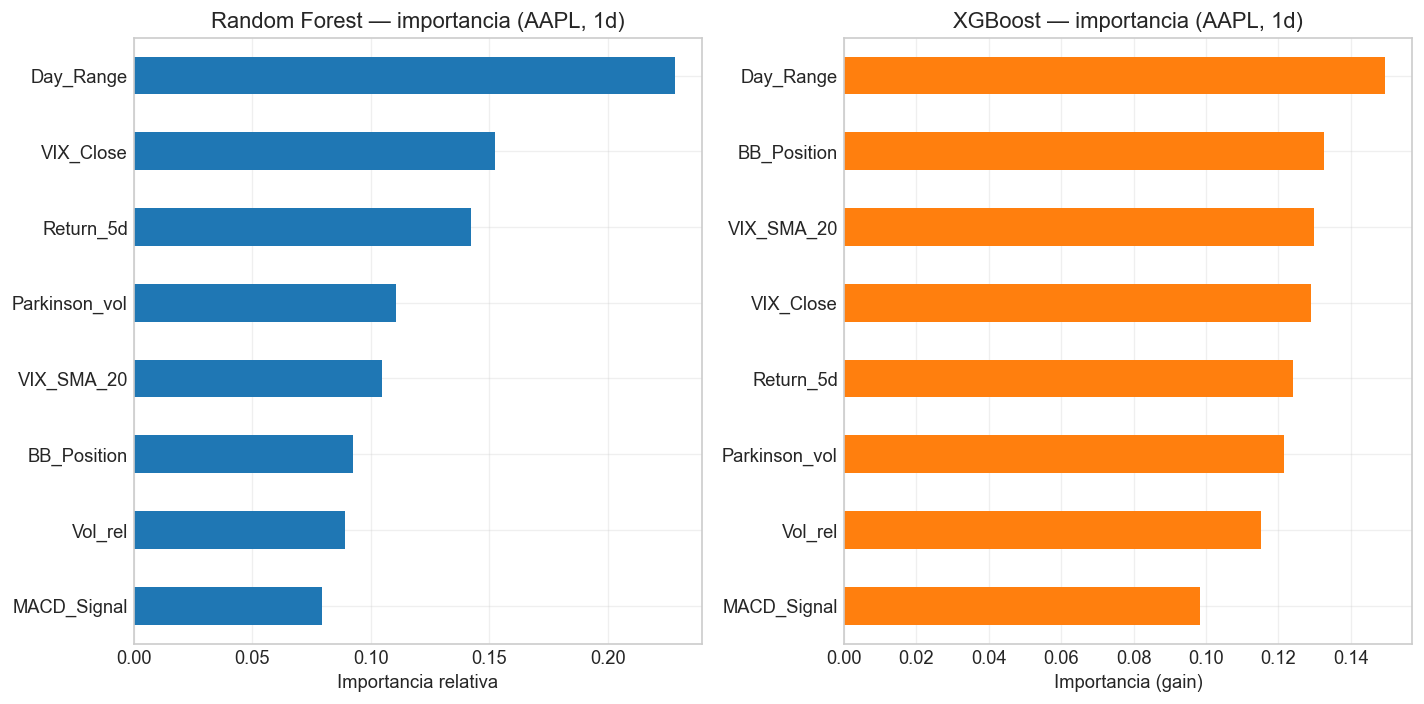


Figura guardada: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Figuras\importancia_rf_xgb_AAPL_1d.png


In [22]:
FI_TICKER  = 'AAPL'
FI_HORIZON = '1d'

ds_fi = datasets[FI_TICKER]
feats_fi = selected_features_xgb.get((FI_TICKER, FI_HORIZON))
all_fi   = list(ds_fi[f'feature_cols_{FI_HORIZON}'])
feat_idx_fi = [all_fi.index(f) for f in feats_fi
               if f in all_fi]

X_tr_fi = ds_fi[f'X_train_{FI_HORIZON}'].values[:, feat_idx_fi]
y_tr_fi = ds_fi[f'y_train_{FI_HORIZON}'].values
X_vl_fi = ds_fi[f'X_val_{FI_HORIZON}'].values[:, feat_idx_fi]
y_vl_fi = ds_fi[f'y_val_{FI_HORIZON}'].values

sc_fi  = StandardScaler()
X_tr_s = sc_fi.fit_transform(X_tr_fi)
X_vl_s = sc_fi.transform(X_vl_fi)

rf_fi = RandomForestRegressor(
    n_estimators=200, max_depth=10, min_samples_split=10,
    n_jobs=-1, random_state=42)
rf_fi.fit(X_tr_s, y_tr_fi)

xgb_fi = xgb.XGBRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0)
xgb_fi.fit(X_tr_s, y_tr_fi)

feat_names = [all_fi[i] for i in feat_idx_fi]
imp_rf  = pd.Series(rf_fi.feature_importances_,
                    index=feat_names).sort_values()
imp_xgb = pd.Series(xgb_fi.feature_importances_,
                    index=feat_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
imp_rf.plot(kind='barh', ax=axes[0], color='tab:blue')
axes[0].set_title(f'Random Forest — importancia '
                   f'({FI_TICKER}, {FI_HORIZON})')
axes[0].set_xlabel('Importancia relativa')

imp_xgb.plot(kind='barh', ax=axes[1], color='tab:orange')
axes[1].set_title(f'XGBoost — importancia '
                   f'({FI_TICKER}, {FI_HORIZON})')
axes[1].set_xlabel('Importancia (gain)')

plt.tight_layout()
fig_path = FIGURES_DIR / 'importancia_rf_xgb_AAPL_1d.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFigura guardada: {fig_path}')

#### 2.9.2 Curvas de entrenamiento de la LSTM

Perdida MSE en train y val durante el ajuste inicial.
`EarlyStopping` interrumpe a paciencia 10 y restaura los mejores
pesos. Interpretacion del patron val < train (dropout +
heterocedasticidad) en la seccion 5.6.2 del TFG.

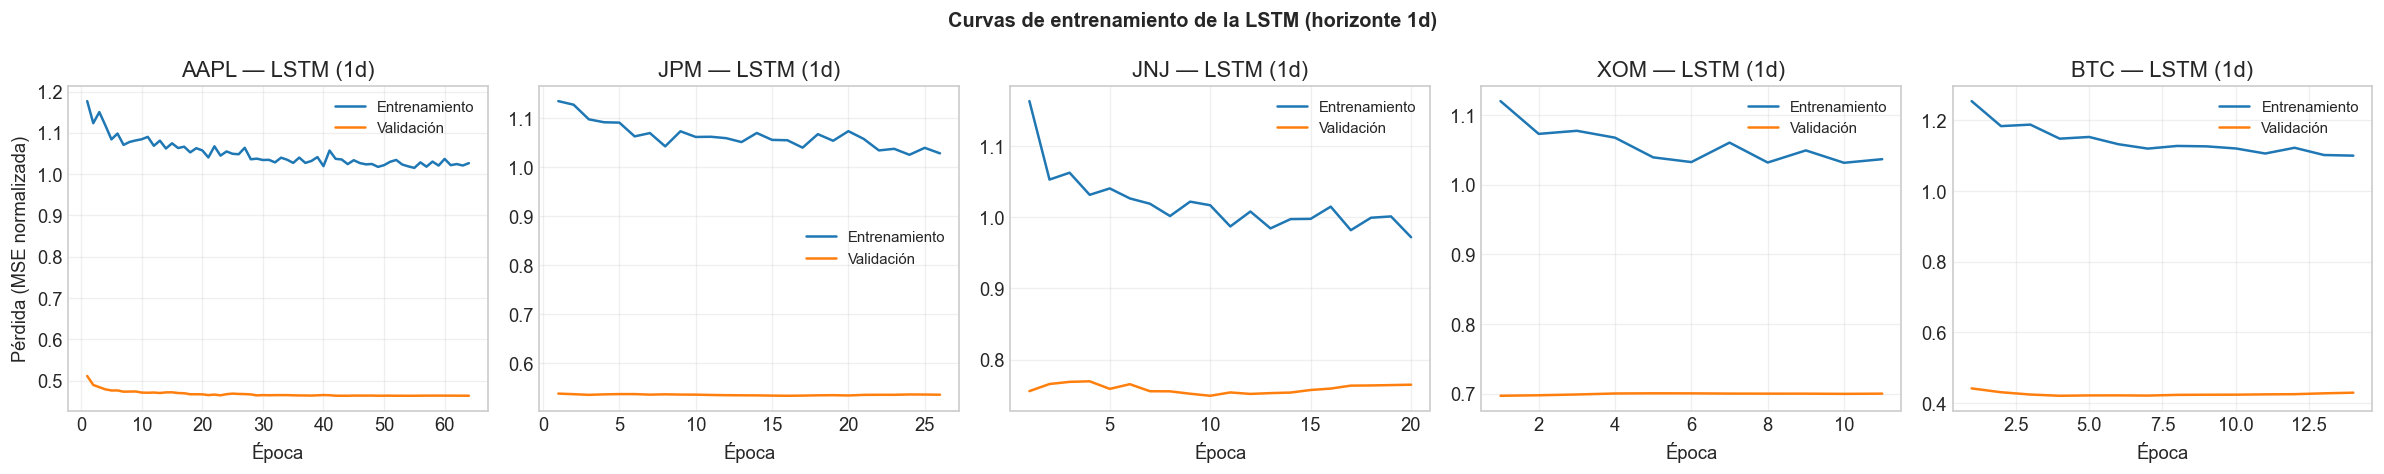

Figura guardada: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Figuras\lstm_training_curves_1d.png


In [23]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4),
                           sharey=False)
for i, t in enumerate(ALL_TICKERS):
    hist = lstm_histories.get((t, '1d'))
    if hist is None:
        axes[i].set_title(f'{t} (sin historial)')
        continue
    epochs = np.arange(1, len(hist['loss']) + 1)
    axes[i].plot(epochs, hist['loss'],
                 label='Entrenamiento', color='tab:blue')
    axes[i].plot(epochs, hist['val_loss'],
                 label='Validación', color='tab:orange')
    axes[i].set_title(f'{t} — LSTM (1d)')
    axes[i].set_xlabel('Época')
    if i == 0:
        axes[i].set_ylabel('Pérdida (MSE normalizada)')
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)
plt.suptitle('Curvas de entrenamiento de la LSTM '
             '(horizonte 1d)', fontsize=12, fontweight='bold')
plt.tight_layout()
fig_path = FIGURES_DIR / 'lstm_training_curves_1d.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {fig_path}')

#### 2.9.3 Retornos reales frente a predichos en el conjunto de test

Superposicion de retornos reales y predichos por XGBoost a 1d en
el periodo de test. Visualiza la contraccion hacia la media tipica
del estimador optimo bajo MSE cuando la senal es debil.

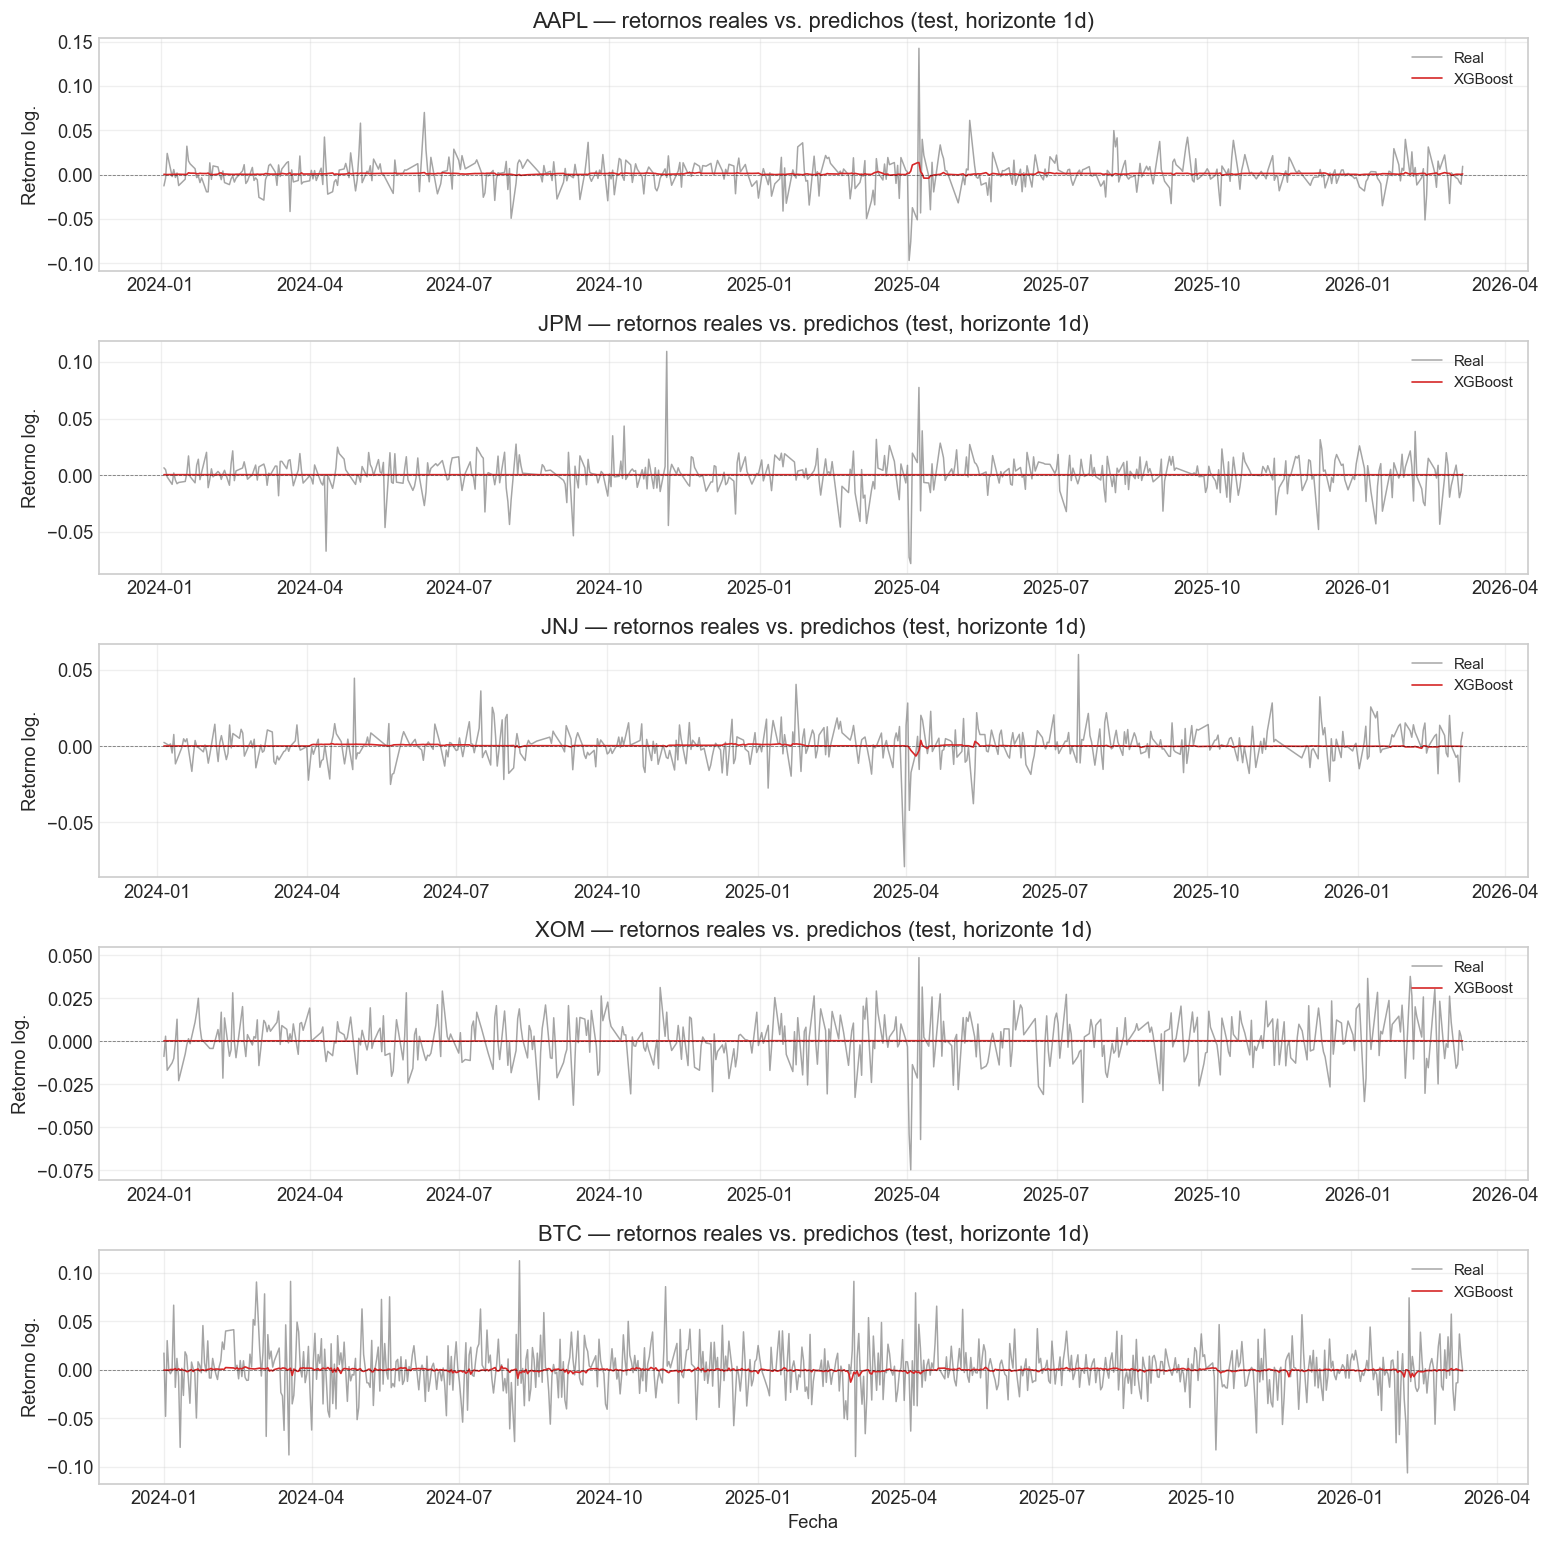

Figura guardada: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Figuras\retornos_real_vs_pred_xgb_1d.png


In [24]:
fig, axes = plt.subplots(5, 1, figsize=(13, 13),
                           sharex=False)
for i, t in enumerate(ALL_TICKERS):
    y_true = datasets[t]['y_test_1d'].values
    y_pred = all_preds_reg.get((t, '1d', 'XGBoost'))
    if y_pred is None:
        axes[i].set_title(f'{t}: sin predicciones XGBoost')
        continue
    idx = datasets[t]['y_test_1d'].index
    axes[i].plot(idx, y_true, label='Real',
                 color='tab:gray', linewidth=0.9, alpha=0.7)
    axes[i].plot(idx, y_pred, label='XGBoost',
                 color='tab:red', linewidth=1.0)
    axes[i].axhline(0, color='black', linewidth=0.5,
                    linestyle='--', alpha=0.5)
    axes[i].set_title(f'{t} — retornos reales vs. predichos '
                      f'(test, horizonte 1d)')
    axes[i].set_ylabel('Retorno log.')
    axes[i].legend(fontsize=9, loc='upper right')
    axes[i].grid(alpha=0.3)
axes[-1].set_xlabel('Fecha')
plt.tight_layout()
fig_path = FIGURES_DIR / 'retornos_real_vs_pred_xgb_1d.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {fig_path}')

### 2.10 Prueba de robustez: perdida de Huber en la LSTM

Re-entrenamiento de la LSTM cambiando la perdida MSE por la de
Huber con $\delta=1,0$ (sobre target estandarizado) para
comprobar si el hallazgo negativo es atribuible al efecto de los
outliers en el gradiente del MSE. Forma funcional y discusion en
la seccion 4.5.5 del TFG. La comparacion
LSTM-MSE frente a LSTM-Huber usa las predicciones de la corrida
original (ambas variantes se entrenaron en la misma sesion), por lo
que el par es internamente consistente; las filas LSTM a cinco dias
de la seccion 2.12 corresponden a la reejecucion descrita en 2.13.


In [25]:
HUBER_DELTA = 1.0


def build_lstm_huber(seq_len, n_features, delta=HUBER_DELTA):
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(16, return_sequences=False),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss=Huber(delta=delta), metrics=['mae'])
    return model


def run_lstm_huber(ticker, ds, horizon='1d', seq_len=SEQ_LEN,
                    retrain_every=RETRAIN_EVERY, epochs=100,
                    batch_size=32, delta=HUBER_DELTA):
    X_tr = ds['X_train'].values
    X_vl = ds['X_val'].values
    X_te = ds['X_test'].values
    y_tr = ds[f'y_train_{horizon}'].values
    y_vl = ds[f'y_val_{horizon}'].values
    y_te = ds[f'y_test_{horizon}'].values
    n_feat = X_tr.shape[1]

    sc_X = StandardScaler(); sc_y = StandardScaler()
    X_pool = sc_X.fit_transform(np.vstack([X_tr, X_vl]))
    X_te_sc = sc_X.transform(X_te)
    y_pool = np.concatenate([y_tr, y_vl])
    y_pool_sc = sc_y.fit_transform(
        y_pool.reshape(-1, 1)).ravel()

    X_tr_seq, y_tr_seq = create_sequences(
        sc_X.transform(X_tr),
        sc_y.transform(y_tr.reshape(-1, 1)).ravel(), seq_len)
    X_vl_seq, y_vl_seq = create_sequences(
        X_pool[len(X_tr)-seq_len+1:len(X_tr)+len(X_vl)],
        y_pool_sc[len(X_tr)-seq_len+1:len(X_tr)+len(X_vl)],
        seq_len)

    model = build_lstm_huber(seq_len, n_feat, delta=delta)
    cb = [EarlyStopping(patience=10,
                         restore_best_weights=True,
                         monitor='val_loss'),
          ReduceLROnPlateau(factor=0.5, patience=5,
                             min_lr=1e-6, verbose=0)]
    hist = model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_vl_seq, y_vl_seq),
        epochs=epochs, batch_size=batch_size,
        callbacks=cb, verbose=0)
    print(f"  {ticker} ({horizon}) Huber: "
          f"{len(hist.history['loss'])} épocas")

    full_X = np.vstack([X_pool, X_te_sc])
    pool_len = len(X_pool)
    preds = []
    for i in progress_iter(range(len(y_te)),
                           desc=f'  {ticker} LSTM-Huber '
                                f'{horizon}', every=100):
        start = max(0, pool_len + i - seq_len + 1)
        x_seq = full_X[start:pool_len+i+1]
        if len(x_seq) < seq_len:
            x_seq = np.pad(
                x_seq, ((seq_len-len(x_seq), 0), (0, 0)),
                mode='edge')
        pred_sc = model.predict(
            x_seq[-seq_len:].reshape(1, seq_len, n_feat),
            verbose=0)[0, 0]
        preds.append(
            sc_y.inverse_transform([[pred_sc]])[0, 0])

        if (i+1) % retrain_every == 0 and i < len(y_te)-1:
            y_obs = np.concatenate([
                y_pool_sc,
                sc_y.transform(
                    y_te[:i+1].reshape(-1, 1)).ravel()])
            X_rt, y_rt = create_sequences(
                full_X[:pool_len+i+1], y_obs, seq_len)
            model.fit(X_rt, y_rt, epochs=10,
                      batch_size=batch_size, verbose=0)
    return np.array(preds)


print("Ejecutando prueba LSTM-Huber...")
all_results_reg_huber = []
all_preds_reg_huber   = {}

for horizon in ['1d', '5d']:
    for t in ALL_TICKERS:
        ds = datasets[t]
        xgb_feats = selected_features_xgb.get((t, horizon))
        feat_key = f'feature_cols_{horizon}'
        all_feats = list(ds[feat_key])
        if xgb_feats is not None:
            feat_idx = [all_feats.index(f) for f in xgb_feats
                        if f in all_feats]
        else:
            feat_idx = list(range(len(all_feats)))

        ds_lstm = {
            'X_train': pd.DataFrame(
                ds[f'X_train_{horizon}'].values[:, feat_idx]),
            'X_val': pd.DataFrame(
                ds[f'X_val_{horizon}'].values[:, feat_idx]),
            'X_test': pd.DataFrame(
                ds[f'X_test_{horizon}'].values[:, feat_idx]),
            f'y_train_{horizon}': ds[f'y_train_{horizon}'],
            f'y_val_{horizon}':   ds[f'y_val_{horizon}'],
            f'y_test_{horizon}':  ds[f'y_test_{horizon}'],
            'feature_cols': list(range(len(feat_idx))),
        }
        y_test = ds[f'y_test_{horizon}'].values
        try:
            y_pred = run_lstm_huber(t, ds_lstm, horizon)
            result = evaluate_regression(
                y_test, y_pred, 'LSTM-Huber', t, horizon)
            all_results_reg_huber.append(result)
            all_preds_reg_huber[
                (t, horizon, 'LSTM-Huber')] = y_pred
        except Exception as e:
            print(f"  Error en LSTM-Huber {t} {horizon}: {e}")

Ejecutando prueba LSTM-Huber...
  AAPL (1d) Huber: 42 épocas
    AAPL LSTM-Huber 1d: 1/517 (0.2%)
    AAPL LSTM-Huber 1d: 100/517 (19.3%)
    AAPL LSTM-Huber 1d: 200/517 (38.7%)
    AAPL LSTM-Huber 1d: 300/517 (58.0%)
    AAPL LSTM-Huber 1d: 400/517 (77.4%)
    AAPL LSTM-Huber 1d: 500/517 (96.7%)
    AAPL LSTM-Huber 1d: 517/517 (100.0%)
AAPL  LSTM-Huber      1d   RMSE: 0.017957 [0.015498, 0.020785]  DA: 0.508 [0.460, 0.551]
  JPM (1d) Huber: 22 épocas
    JPM LSTM-Huber 1d: 1/512 (0.2%)
    JPM LSTM-Huber 1d: 100/512 (19.5%)
    JPM LSTM-Huber 1d: 200/512 (39.1%)
    JPM LSTM-Huber 1d: 300/512 (58.6%)
    JPM LSTM-Huber 1d: 400/512 (78.1%)
    JPM LSTM-Huber 1d: 500/512 (97.7%)
    JPM LSTM-Huber 1d: 512/512 (100.0%)
JPM   LSTM-Huber      1d   RMSE: 0.015735 [0.013692, 0.017981]  DA: 0.546 [0.502, 0.588]
  JNJ (1d) Huber: 14 épocas
    JNJ LSTM-Huber 1d: 1/511 (0.2%)
    JNJ LSTM-Huber 1d: 100/511 (19.6%)
    JNJ LSTM-Huber 1d: 200/511 (39.1%)
    JNJ LSTM-Huber 1d: 300/511 (58.7%)
   

In [26]:
# Tabla comparativa LSTM-MSE vs LSTM-Huber
results_reg_df = pd.DataFrame(all_results_reg)
results_huber_df = pd.DataFrame(all_results_reg_huber)

for horizon in ['1d', '5d']:
    print(f'\n{"="*102}')
    print(f'  LSTM-MSE vs LSTM-HUBER — Horizonte {horizon}')
    print(f'{"="*102}')
    print(f'  {"Ticker":6s} {"Modelo":12s} {"RMSE":>10s} '
          f'{"DA":>8s} {"ΔRMSE %":>10s} {"ΔDA (pp)":>10s}')
    print(f'  {"-"*92}')
    sub_mse = results_reg_df[
        (results_reg_df['Horizon'] == horizon)
        & (results_reg_df['Model'] == 'LSTM')]
    sub_hub = results_huber_df[
        results_huber_df['Horizon'] == horizon]
    for t in ALL_TICKERS:
        r_m = sub_mse[sub_mse['Ticker'] == t]
        r_h = sub_hub[sub_hub['Ticker'] == t]
        if r_m.empty or r_h.empty:
            continue
        rm, rh = r_m['RMSE'].iloc[0], r_h['RMSE'].iloc[0]
        dm, dh = r_m['DA'].iloc[0],   r_h['DA'].iloc[0]
        drmse = 100 * (rh - rm) / rm
        dda   = 100 * (dh - dm)
        print(f'  {t:6s} {"LSTM (MSE)":12s} {rm:10.6f} '
              f'{dm:8.3f} {"":>10s} {"":>10s}')
        print(f'  {"":6s} {"LSTM-Huber":12s} {rh:10.6f} '
              f'{dh:8.3f} {drmse:+10.2f} {dda:+10.2f}')
        print()

if DM_AVAILABLE:
    print(f'\n{"="*90}')
    print(f'  DIEBOLD-MARIANO: LSTM-MSE vs LSTM-Huber')
    print(f'{"="*90}')
    for horizon in ['1d', '5d']:
        for t in ALL_TICKERS:
            key_m = (t, horizon, 'LSTM')
            key_h = (t, horizon, 'LSTM-Huber')
            if (key_m not in all_preds_reg
                    or key_h not in all_preds_reg_huber):
                continue
            y_true = datasets[t][f'y_test_{horizon}'].values
            try:
                dm_stat, p_val = dm_test(
                    y_true,
                    all_preds_reg[key_m],
                    all_preds_reg_huber[key_h],
                    h=1 if horizon == '1d' else 5)
                if p_val < 0.05:
                    concl = ('Huber mejora' if dm_stat > 0
                             else 'MSE mejora')
                else:
                    concl = 'Sin diferencia'
                print(f'  {t:6s} {horizon:3s} '
                      f'DM={dm_stat:+7.3f} '
                      f'p={p_val:7.4f}  {concl}')
            except Exception as e:
                print(f'  {t:6s} {horizon:3s} error: {e}')


  LSTM-MSE vs LSTM-HUBER — Horizonte 1d
  Ticker Modelo             RMSE       DA    ΔRMSE %   ΔDA (pp)
  --------------------------------------------------------------------------------------------
  AAPL   LSTM (MSE)     0.017998    0.504                      
         LSTM-Huber     0.017957    0.508      -0.23      +0.39

  JPM    LSTM (MSE)     0.016166    0.497                      
         LSTM-Huber     0.015735    0.546      -2.66      +4.89

  JNJ    LSTM (MSE)     0.011291    0.468                      
         LSTM-Huber     0.011135    0.511      -1.39      +4.31

  XOM    LSTM (MSE)     0.014275    0.488                      
         LSTM-Huber     0.014583    0.461      +2.16      -2.70

  BTC    LSTM (MSE)     0.025786    0.505                      
         LSTM-Huber     0.025393    0.499      -1.52      -0.65


  LSTM-MSE vs LSTM-HUBER — Horizonte 5d
  Ticker Modelo             RMSE       DA    ΔRMSE %   ΔDA (pp)
  ------------------------------------------------

### 2.11 Curva de validacion del XGBoost

Curva de validacion sobre AAPL 1d para `max_depth` y
`learning_rate` (los hiperparametros mas influyentes). Se grafican
las curvas de train y val y el `generalization gap`, que da una
lectura directa del sobreajuste para cada valor.

Calculando curva de validación (AAPL, 1d)...


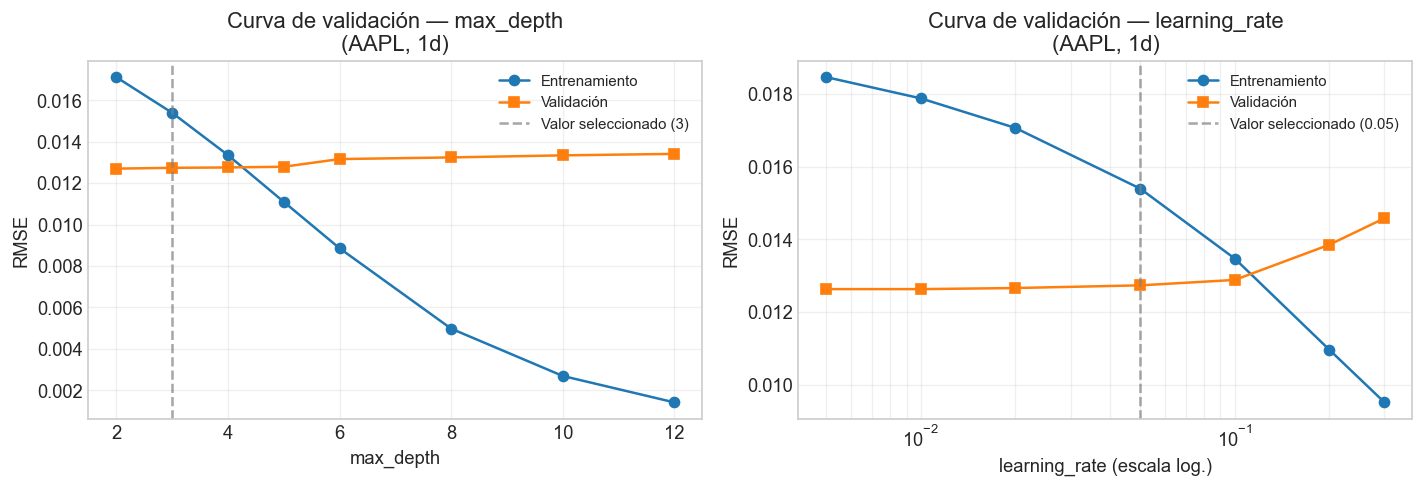


Figura guardada: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Figuras\validation_curve_xgb_AAPL_1d.png


In [27]:
VC_TICKER  = 'AAPL'
VC_HORIZON = '1d'

base_params = dict(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=1.0,
    gamma=0.0, reg_alpha=0.0, reg_lambda=1.0,
    random_state=42, verbosity=0)

ds_vc = datasets[VC_TICKER]
xgb_feats_vc = selected_features_xgb.get(
    (VC_TICKER, VC_HORIZON))
all_feats_vc = list(ds_vc[f'feature_cols_{VC_HORIZON}'])
feat_idx_vc = [all_feats_vc.index(f) for f in xgb_feats_vc
               if f in all_feats_vc]

X_tr_vc = ds_vc[f'X_train_{VC_HORIZON}'].values[:, feat_idx_vc]
y_tr_vc = ds_vc[f'y_train_{VC_HORIZON}'].values
X_vl_vc = ds_vc[f'X_val_{VC_HORIZON}'].values[:, feat_idx_vc]
y_vl_vc = ds_vc[f'y_val_{VC_HORIZON}'].values

sc_vc = StandardScaler()
X_tr_s = sc_vc.fit_transform(X_tr_vc)
X_vl_s = sc_vc.transform(X_vl_vc)


def _vc_eval(param_name, param_values):
    tr_rmse, vl_rmse = [], []
    for v in param_values:
        params = {**base_params, param_name: v}
        mdl = xgb.XGBRegressor(**params)
        mdl.fit(X_tr_s, y_tr_vc)
        tr_rmse.append(np.sqrt(
            mean_squared_error(y_tr_vc, mdl.predict(X_tr_s))))
        vl_rmse.append(np.sqrt(
            mean_squared_error(y_vl_vc, mdl.predict(X_vl_s))))
    return np.array(tr_rmse), np.array(vl_rmse)


depths = [2, 3, 4, 5, 6, 8, 10, 12]
lrs    = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]

print(f'Calculando curva de validación '
      f'({VC_TICKER}, {VC_HORIZON})...')
rmse_tr_d,  rmse_vl_d  = _vc_eval('max_depth', depths)
rmse_tr_lr, rmse_vl_lr = _vc_eval('learning_rate', lrs)

depth_sel = base_params['max_depth']
lr_sel    = base_params['learning_rate']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(depths, rmse_tr_d, 'o-',
             label='Entrenamiento', color='tab:blue')
axes[0].plot(depths, rmse_vl_d, 's-',
             label='Validación', color='tab:orange')
axes[0].axvline(depth_sel, ls='--', color='gray', alpha=0.7,
                label=f'Valor seleccionado ({depth_sel})')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('RMSE')
axes[0].set_title(f'Curva de validación — max_depth\n'
                  f'({VC_TICKER}, {VC_HORIZON})')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(lrs, rmse_tr_lr, 'o-',
             label='Entrenamiento', color='tab:blue')
axes[1].plot(lrs, rmse_vl_lr, 's-',
             label='Validación', color='tab:orange')
axes[1].axvline(lr_sel, ls='--', color='gray', alpha=0.7,
                label=f'Valor seleccionado ({lr_sel})')
axes[1].set_xscale('log')
axes[1].set_xlabel('learning_rate (escala log.)')
axes[1].set_ylabel('RMSE')
axes[1].set_title(f'Curva de validación — learning_rate\n'
                  f'({VC_TICKER}, {VC_HORIZON})')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
fig_path = (FIGURES_DIR /
            f'validation_curve_xgb_{VC_TICKER}_{VC_HORIZON}.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFigura guardada: {fig_path}')

### 2.12 Resumen de resultados de regresion

Consolidacion de las metricas en un DataFrame para exportarlo y
mostrarlo de forma compacta.

In [28]:
results_reg_df = pd.DataFrame(all_results_reg)
MODELS_ORDER = ['Naïve', 'ARIMA', 'Random Forest',
                'XGBoost', 'LSTM']

for horizon in ['1d', '5d']:
    print(f'\n{"="*90}')
    print(f'  RESULTADOS DE REGRESIÓN — Horizonte {horizon}')
    print(f'{"="*90}')
    sub = results_reg_df[results_reg_df['Horizon'] == horizon]
    for t in ALL_TICKERS:
        print(f'\n  {t}')
        print(f'  {"-"*80}')
        tsub = sub[sub['Ticker'] == t].set_index('Model')
        for m in [x for x in MODELS_ORDER if x in tsub.index]:
            r = tsub.loc[m]
            print(f"  {m:15s}  "
                  f"RMSE: {r['RMSE']:.6f} "
                  f"[{r['RMSE_CI_low']:.6f}, "
                  f"{r['RMSE_CI_high']:.6f}]  "
                  f"DA: {r['DA']:.3f} "
                  f"[{r['DA_CI_low']:.3f}, "
                  f"{r['DA_CI_high']:.3f}]  "
                  f"R²: {r['R2']:+.4f}")


  RESULTADOS DE REGRESIÓN — Horizonte 1d

  AAPL
  --------------------------------------------------------------------------------
  Naïve            RMSE: 0.017627 [0.015191, 0.020462]  DA: 0.000 [0.000, 0.000]  R²: -0.0015
  ARIMA            RMSE: 0.017745 [0.015390, 0.020428]  DA: 0.484 [0.440, 0.524]  R²: -0.0150
  Random Forest    RMSE: 0.017838 [0.015216, 0.020855]  DA: 0.548 [0.507, 0.590]  R²: -0.0257
  XGBoost          RMSE: 0.017603 [0.015367, 0.020222]  DA: 0.523 [0.479, 0.566]  R²: +0.0012
  LSTM             RMSE: 0.017998 [0.015631, 0.020717]  DA: 0.504 [0.460, 0.547]  R²: -0.0442

  JPM
  --------------------------------------------------------------------------------
  Naïve            RMSE: 0.015759 [0.013780, 0.018048]  DA: 0.000 [0.000, 0.000]  R²: -0.0043
  ARIMA            RMSE: 0.015815 [0.013783, 0.018226]  DA: 0.544 [0.500, 0.588]  R²: -0.0116
  Random Forest    RMSE: 0.015819 [0.013795, 0.018087]  DA: 0.550 [0.505, 0.591]  R²: -0.0121
  XGBoost          RMSE: 

### 2.13 Test de Diebold-Mariano

Test DM con HAC y correccion de Harvey, Leybourne y Newbold (1997)
para todos los pares de modelos en cada activo y horizonte. El
p-valor se interpreta como evidencia contra la hipotesis nula de
igual capacidad predictiva. El parametro h del test se fija igual
al horizonte de prediccion: h=1 en el diario y h=5 en el de cinco
dias, de modo que el estimador de la varianza incorpora las
autocovarianzas inducidas por el solapamiento del target. En el
horizonte de cinco dias se excluyen los pares con ARIMA: la
variante con fuga no es un contraste valido y la variante sin fuga
se contrasta por separado en la seccion 2.16. Las predicciones de
la LSTM a cinco dias provienen de la reejecucion documentada en
anexo_correcciones_v2.ipynb (misma configuracion y semillas; los
modelos deterministas reproducen la corrida original al decimal).


In [29]:
if DM_AVAILABLE:
    dm_all = []
    for horizon in ['1d', '5d']:
        print(f'\n{"="*70}')
        print(f'  TEST DE DIEBOLD-MARIANO — Horizonte {horizon}')
        print(f'{"="*70}')
        for t in ALL_TICKERS:
            y_true = datasets[t][f'y_test_{horizon}'].values
            m_preds = {
                m: all_preds_reg[(t, horizon, m)]
                for m in MODELS_ORDER
                if (t, horizon, m) in all_preds_reg
                and len(all_preds_reg[
                    (t, horizon, m)]) == len(y_true)}
            if len(m_preds) < 2:
                continue
            sig_found = False
            for m1, m2 in itertools.combinations(
                    m_preds.keys(), 2):
                if horizon == '5d' and 'ARIMA' in (m1, m2):
                    continue  # ARIMA 5d: ver seccion 2.16
                try:
                    stat, pval = dm_test(
                        y_true, m_preds[m1], m_preds[m2],
                        h=1 if horizon == '1d' else 5)
                    if pval < 0.05:
                        if not sig_found:
                            print(f'\n  {t}')
                            sig_found = True
                        stars = ('***' if pval < 0.001
                                 else '**' if pval < 0.01
                                 else '*')
                        winner = m1 if stat < 0 else m2
                        print(f"    {m1:15s} vs {m2:15s}  "
                              f"DM={stat:+.3f}  "
                              f"p={pval:.4f} {stars}  "
                              f"-> {winner}")
                        dm_all.append({
                            'Ticker': t, 'Horizon': horizon,
                            'Model1': m1, 'Model2': m2,
                            'DM_stat': stat, 'p_value': pval,
                            'Winner': winner})
                except Exception:
                    pass
else:
    print("Test de Diebold-Mariano no disponible. "
          "pip install dieboldmariano")



  TEST DE DIEBOLD-MARIANO — Horizonte 1d

  AAPL
    XGBoost         vs LSTM             DM=-2.132  p=0.0335 *  -> XGBoost

  JPM
    Naïve           vs LSTM             DM=-2.507  p=0.0125 *  -> Naïve
    XGBoost         vs LSTM             DM=-2.534  p=0.0116 *  -> XGBoost

  JNJ
    Naïve           vs LSTM             DM=-2.154  p=0.0317 *  -> Naïve
    Random Forest   vs LSTM             DM=-2.079  p=0.0381 *  -> Random Forest
    XGBoost         vs LSTM             DM=-2.751  p=0.0061 **  -> XGBoost

  XOM
    Naïve           vs LSTM             DM=-2.489  p=0.0131 *  -> Naïve
    ARIMA           vs LSTM             DM=-2.541  p=0.0113 *  -> ARIMA
    Random Forest   vs LSTM             DM=-2.150  p=0.0320 *  -> Random Forest
    XGBoost         vs LSTM             DM=-2.584  p=0.0100 *  -> XGBoost

  BTC
    Naïve           vs Random Forest    DM=-2.462  p=0.0140 *  -> Naïve
    Naïve           vs LSTM             DM=-2.925  p=0.0035 **  -> Naïve
    ARIMA           vs Random Fo

### 2.14 Parte B: Clasificacion binaria

Reformulacion como clasificacion: $y=1$ si el retorno del dia
siguiente es positivo, $y=0$ en caso contrario. El baseline Naive
predice la clase mayoritaria del train. La LSTM cambia la
activacion final a sigmoide y la perdida a entropia cruzada
binaria; el resto de la arquitectura se mantiene.

In [30]:
def run_rf_cls(ticker, ds, retrain_every=RETRAIN_EVERY):
    X_tr = ds['X_train_1d'].values
    X_vl = ds['X_val_1d'].values
    X_te = ds['X_test_1d'].values
    y_tr = ds['y_train_cls'].values
    y_vl = ds['y_val_cls'].values
    y_te = ds['y_test_cls'].values

    scaler_s = StandardScaler()
    X_search = scaler_s.fit_transform(np.vstack([X_tr, X_vl]))
    y_search = np.concatenate([y_tr, y_vl])
    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = [{'n_estimators': n, 'max_depth': d,
                   'min_samples_split': s}
                  for n in [100, 200, 300]
                  for d in [5, 10, 15]
                  for s in [5, 10, 20]]
    best_score, best_params = -np.inf, {}
    for params in param_grid:
        scores = []
        for tr_i, vl_i in tscv.split(X_search):
            clf = RandomForestClassifier(
                **params, n_jobs=-1, random_state=42)
            clf.fit(X_search[tr_i], y_search[tr_i])
            scores.append(accuracy_score(
                y_search[vl_i], clf.predict(X_search[vl_i])))
        if np.mean(scores) > best_score:
            best_score, best_params = np.mean(scores), params

    X_pool = np.vstack([X_tr, X_vl])
    y_pool = np.concatenate([y_tr, y_vl])
    preds = []
    for i in progress_iter(range(len(y_te)),
                           desc=f'  {ticker} RF-Cls',
                           every=100):
        if i == 0 or i % retrain_every == 0:
            sc = StandardScaler()
            end = (len(X_pool) - len(y_te) + i
                   if i > 0 else len(X_pool))
            X_fit = sc.fit_transform(X_pool[:end])
            clf = RandomForestClassifier(
                **best_params, n_jobs=-1, random_state=42)
            clf.fit(X_fit, y_pool[:end])
        preds.append(clf.predict(sc.transform(X_te[i:i+1]))[0])
    return np.array(preds)


def run_xgb_cls(ticker, ds, retrain_every=RETRAIN_EVERY):
    X_tr = ds['X_train_1d'].values
    X_vl = ds['X_val_1d'].values
    X_te = ds['X_test_1d'].values
    y_tr = ds['y_train_cls'].values
    y_vl = ds['y_val_cls'].values
    y_te = ds['y_test_cls'].values

    scaler_s = StandardScaler()
    X_search = scaler_s.fit_transform(np.vstack([X_tr, X_vl]))
    y_search = np.concatenate([y_tr, y_vl])
    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = [{'n_estimators': n, 'max_depth': d,
                   'learning_rate': lr, 'subsample': ss,
                   'colsample_bytree': cs}
                  for n in [100, 200] for d in [3, 5, 7]
                  for lr in [0.01, 0.05]
                  for ss in [0.7, 0.8]
                  for cs in [0.7, 0.8, 1.0]]
    best_score, best_params = -np.inf, {}
    for params in param_grid:
        scores = []
        for tr_i, vl_i in tscv.split(X_search):
            clf = xgb.XGBClassifier(
                **params, random_state=42, verbosity=0,
                eval_metric='logloss')
            clf.fit(X_search[tr_i], y_search[tr_i])
            scores.append(accuracy_score(
                y_search[vl_i], clf.predict(X_search[vl_i])))
        if np.mean(scores) > best_score:
            best_score, best_params = np.mean(scores), params

    X_pool = np.vstack([X_tr, X_vl])
    y_pool = np.concatenate([y_tr, y_vl])
    preds = []
    for i in progress_iter(range(len(y_te)),
                           desc=f'  {ticker} XGB-Cls',
                           every=100):
        if i == 0 or i % retrain_every == 0:
            sc = StandardScaler()
            end = (len(X_pool) - len(y_te) + i
                   if i > 0 else len(X_pool))
            X_fit = sc.fit_transform(X_pool[:end])
            clf = xgb.XGBClassifier(
                **best_params, random_state=42,
                verbosity=0, eval_metric='logloss')
            clf.fit(X_fit, y_pool[:end])
        preds.append(clf.predict(sc.transform(X_te[i:i+1]))[0])
    return np.array(preds)


def build_lstm_cls(seq_len, n_features):
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(16, return_sequences=False),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


def run_lstm_cls(ticker, ds, seq_len=SEQ_LEN,
                  epochs=100, batch_size=32):
    X_tr = ds['X_train_1d'].values
    X_vl = ds['X_val_1d'].values
    X_te = ds['X_test_1d'].values
    y_tr = ds['y_train_cls'].values
    y_vl = ds['y_val_cls'].values
    y_te = ds['y_test_cls'].values
    n_feat = X_tr.shape[1]

    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_vl_sc = sc.transform(X_vl)
    X_te_sc = sc.transform(X_te)
    X_pool = np.vstack([X_tr_sc, X_vl_sc])
    y_pool = np.concatenate([y_tr, y_vl])

    X_tr_seq, y_tr_seq = create_sequences(X_tr_sc, y_tr, seq_len)
    start_v = len(X_tr_sc) - seq_len + 1
    end_v   = len(X_tr_sc) + len(X_vl_sc)
    X_vl_seq, y_vl_seq = create_sequences(
        X_pool[start_v:end_v], y_pool[start_v:end_v], seq_len)

    model = build_lstm_cls(seq_len, n_feat)
    cb = [EarlyStopping(patience=10,
                         restore_best_weights=True,
                         monitor='val_loss')]
    hist = model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_vl_seq, y_vl_seq),
        epochs=epochs, batch_size=batch_size,
        callbacks=cb, verbose=0)
    print(f"  {ticker}: entrenado "
          f"{len(hist.history['loss'])} épocas")

    full_X = np.vstack([X_pool, X_te_sc])
    pool_len = len(X_pool)
    preds = []
    for i in progress_iter(range(len(y_te)),
                           desc=f'  {ticker} LSTM-Cls',
                           every=100):
        start = max(0, pool_len + i - seq_len + 1)
        x_seq = full_X[start:pool_len+i+1]
        if len(x_seq) < seq_len:
            x_seq = np.pad(
                x_seq, ((seq_len-len(x_seq), 0), (0, 0)),
                mode='edge')
        prob = model.predict(
            x_seq[-seq_len:].reshape(1, seq_len, n_feat),
            verbose=0)[0, 0]
        preds.append(int(prob >= 0.5))
    return np.array(preds)

In [31]:
all_results_cls = []
print('\n' + '='*70)
print('  PARTE B: CLASIFICACIÓN BINARIA — Target 1d')
print('='*70)

for t in ALL_TICKERS:
    ds = datasets[t]
    y_test = ds['y_test_cls'].values
    print(f'\n  {t}')
    print(f'  {"-"*60}')

    majority = int(ds['y_train_cls'].values.mean() >= 0.5)
    y_pred = np.full(len(y_test), majority)
    all_results_cls.append(evaluate_classification(
        y_test, y_pred, 'Naïve (mayoría)', t))

    try:
        y_pred = run_rf_cls(t, ds)
        all_results_cls.append(evaluate_classification(
            y_test, y_pred, 'RF Classifier', t))
    except Exception as e:
        print(f'  Error en RF Classifier: {e}')

    try:
        y_pred = run_xgb_cls(t, ds)
        all_results_cls.append(evaluate_classification(
            y_test, y_pred, 'XGB Classifier', t))
    except Exception as e:
        print(f'  Error en XGB Classifier: {e}')

    try:
        y_pred = run_lstm_cls(t, ds)
        all_results_cls.append(evaluate_classification(
            y_test, y_pred, 'LSTM Classifier', t))
    except Exception as e:
        print(f'  Error en LSTM Classifier: {e}')


  PARTE B: CLASIFICACIÓN BINARIA — Target 1d

  AAPL
  ------------------------------------------------------------
AAPL  Naïve (mayoría)  Acc: 0.538  Prec: 0.538  Rec: 1.000  F1: 0.699
    AAPL RF-Cls: 1/517 (0.2%)
    AAPL RF-Cls: 100/517 (19.3%)
    AAPL RF-Cls: 200/517 (38.7%)
    AAPL RF-Cls: 300/517 (58.0%)
    AAPL RF-Cls: 400/517 (77.4%)
    AAPL RF-Cls: 500/517 (96.7%)
    AAPL RF-Cls: 517/517 (100.0%)
AAPL  RF Classifier    Acc: 0.499  Prec: 0.531  Rec: 0.590  F1: 0.559
    AAPL XGB-Cls: 1/517 (0.2%)
    AAPL XGB-Cls: 100/517 (19.3%)
    AAPL XGB-Cls: 200/517 (38.7%)
    AAPL XGB-Cls: 300/517 (58.0%)
    AAPL XGB-Cls: 400/517 (77.4%)
    AAPL XGB-Cls: 500/517 (96.7%)
    AAPL XGB-Cls: 517/517 (100.0%)
AAPL  XGB Classifier   Acc: 0.507  Prec: 0.528  Rec: 0.781  F1: 0.630
  AAPL: entrenado 17 épocas
    AAPL LSTM-Cls: 1/517 (0.2%)
    AAPL LSTM-Cls: 100/517 (19.3%)
    AAPL LSTM-Cls: 200/517 (38.7%)
    AAPL LSTM-Cls: 300/517 (58.0%)
    AAPL LSTM-Cls: 400/517 (77.4%)
    AAPL

### 2.15 Exportacion de resultados del bloque 2

Guardado de las metricas de regresion y clasificacion en CSV
dentro de `Resultados/`.

In [32]:
results_reg_df = pd.DataFrame(all_results_reg)
results_reg_df.to_csv(
    RESULTS_DIR / 'metricas_regresion_v4.csv', index=False)
print(f'Regresión guardada: '
      f'{RESULTS_DIR / "metricas_regresion_v4.csv"}')

results_cls_df = pd.DataFrame(all_results_cls)
results_cls_df.to_csv(
    RESULTS_DIR / 'metricas_clasificacion_v4.csv', index=False)
print(f'Clasificación guardada: '
      f'{RESULTS_DIR / "metricas_clasificacion_v4.csv"}')

feats_rows = []
for (t, horizon), feats in selected_features_rf.items():
    for i, f in enumerate(feats):
        feats_rows.append({'Ticker': t, 'Horizon': horizon,
                            'Model_group': 'RF',
                            'Rank': i+1, 'Feature': f})
for (t, horizon), feats in selected_features_xgb.items():
    for i, f in enumerate(feats):
        feats_rows.append({'Ticker': t, 'Horizon': horizon,
                            'Model_group': 'XGB_LSTM',
                            'Rank': i+1, 'Feature': f})
pd.DataFrame(feats_rows).to_csv(
    RESULTS_DIR / 'features_seleccionadas_v4.csv', index=False)
print(f'Features guardadas: '
      f'{RESULTS_DIR / "features_seleccionadas_v4.csv"}')

if DM_AVAILABLE and 'dm_all' in dir() and dm_all:
    pd.DataFrame(dm_all).to_csv(
        RESULTS_DIR / 'diebold_mariano_v4.csv', index=False)
    print(f'DM guardado: '
          f'{RESULTS_DIR / "diebold_mariano_v4.csv"}')

Regresión guardada: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Resultados\metricas_regresion_v4.csv
Clasificación guardada: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Resultados\metricas_clasificacion_v4.csv
Features guardadas: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Resultados\features_seleccionadas_v4.csv
DM guardado: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Resultados\diebold_mariano_v4.csv


### 2.16 Prueba de robustez: ARIMA a 5 dias sin look-ahead bias

Variante del walk-forward del ARIMA 5d que solo incorpora al
filtro de Kalman observaciones del target con $k \leq t-5$, es
decir, calculables a partir de precios observables en el instante
$t$. El R^2 elevado del ARIMA 5d original era artefacto del
solapamiento de la ventana del target. Diagnostico completo en el
seccion 5.3.1 del TFG.

In [33]:
def run_arima_5d_noleak(ticker, ds, refit_every=20):
    warnings.filterwarnings('ignore')
    H = 5
    y_all = np.concatenate([
        ds['y_train_5d'].values,
        ds['y_val_5d'].values,
        ds['y_test_5d'].values])
    n_pre  = len(ds['y_train_5d']) + len(ds['y_val_5d'])
    n_test = len(ds['y_test_5d'])

    train_ret = y_all[:n_pre - H + 1]
    auto_model = auto_arima(
        train_ret, start_p=0, start_q=0, max_p=5, max_q=5,
        d=0, seasonal=False, stepwise=True,
        suppress_warnings=True)
    order = auto_model.order
    print(f"  {ticker} (5d, sin leakage): "
          f"auto_arima -> {order}")

    model = sm.tsa.ARIMA(train_ret, order=order).fit()
    preds = []
    for i in progress_iter(range(n_test),
                           desc=f'  {ticker} ARIMA 5d '
                                f'(sin leakage)',
                           every=100):
        fcst = model.forecast(steps=H)
        preds.append(fcst[-1])
        new_idx = n_pre - H + i + 1
        if new_idx < len(y_all):
            if (i + 1) % refit_every == 0:
                try:
                    model = sm.tsa.ARIMA(
                        y_all[:new_idx + 1],
                        order=order).fit()
                except Exception:
                    pass
            else:
                try:
                    model = model.append(
                        [y_all[new_idx]], refit=False)
                except Exception:
                    pass
    return np.array(preds)


print('Ejecutando ARIMA 5d walk-forward sin leakage...\n')
arima_noleak_results = []
arima_noleak_preds   = {}
for t in ALL_TICKERS:
    ds = datasets[t]
    y_test = ds['y_test_5d'].values
    try:
        y_pred = run_arima_5d_noleak(t, ds)
        result = evaluate_regression(
            y_test, y_pred, 'ARIMA (sin leakage)', t, '5d')
        arima_noleak_results.append(result)
        arima_noleak_preds[t] = y_pred
    except Exception as e:
        print(f'  Error ARIMA sin leakage {t} 5d: {e}')


# Tabla comparativa
print(f'\n{"="*100}')
print(f'  5d: Naïve — ARIMA (con leakage) — '
      f'ARIMA (sin leakage)')
print(f'{"="*100}')
print(f'  {"Ticker":6s} {"Modelo":22s} '
      f'{"RMSE":>10s} {"DA":>8s} {"R²":>8s}')
print(f'  {"-"*90}')

results_reg_df_local = pd.DataFrame(all_results_reg)
noleak_df = pd.DataFrame(arima_noleak_results)

for t in ALL_TICKERS:
    naive = results_reg_df_local[
        (results_reg_df_local.Ticker == t)
        & (results_reg_df_local.Horizon == '5d')
        & (results_reg_df_local.Model == 'Naïve')].iloc[0]
    leaky = results_reg_df_local[
        (results_reg_df_local.Ticker == t)
        & (results_reg_df_local.Horizon == '5d')
        & (results_reg_df_local.Model == 'ARIMA')].iloc[0]
    clean_rows = noleak_df[noleak_df.Ticker == t]
    if clean_rows.empty:
        continue
    clean = clean_rows.iloc[0]
    for label, r in [('Naïve', naive),
                     ('ARIMA (leakage)', leaky),
                     ('ARIMA (sin leakage)', clean)]:
        print(f'  {t:6s} {label:22s} '
              f'{r["RMSE"]:10.6f} {r["DA"]:8.3f} '
              f'{r["R2"]:+8.4f}')
    print()


if DM_AVAILABLE:
    print(f'\n{"="*90}')
    print(f'  DM: ARIMA (sin leakage) vs Naïve  [h=5]')
    print(f'{"="*90}')
    dm_rows = []
    for t in ALL_TICKERS:
        y_true = datasets[t]['y_test_5d'].values
        y_naive = np.zeros(len(y_true))
        y_clean = arima_noleak_preds.get(t)
        if y_clean is None:
            continue
        try:
            dm_stat, p_val = dm_test(
                y_true, y_naive, y_clean, h=5)
            if p_val < 0.05:
                concl = ('ARIMA mejor' if dm_stat > 0
                         else 'Naïve mejor')
            else:
                concl = 'sin diferencia'
            print(f'  {t:6s} DM={dm_stat:+7.3f} '
                  f'p={p_val:8.4g}  {concl}')
            dm_rows.append({
                'Ticker': t, 'Horizon': '5d',
                'Model1': 'Naïve',
                'Model2': 'ARIMA (sin leakage)',
                'DM_stat': dm_stat, 'p_value': p_val,
                'Conclusion': concl})
        except Exception as e:
            print(f'  {t:6s}  error: {e}')


noleak_df.to_csv(
    RESULTS_DIR / 'arima_5d_noleak_v4.csv', index=False)
if DM_AVAILABLE and 'dm_rows' in dir():
    pd.DataFrame(dm_rows).to_csv(
        RESULTS_DIR / 'arima_5d_noleak_dm_v4.csv',
        index=False)
print(f'\nResultados guardados en {RESULTS_DIR}')

Ejecutando ARIMA 5d walk-forward sin leakage...

  AAPL (5d, sin leakage): auto_arima -> (3, 0, 4)
    AAPL ARIMA 5d (sin leakage): 1/517 (0.2%)
    AAPL ARIMA 5d (sin leakage): 100/517 (19.3%)
    AAPL ARIMA 5d (sin leakage): 200/517 (38.7%)
    AAPL ARIMA 5d (sin leakage): 300/517 (58.0%)
    AAPL ARIMA 5d (sin leakage): 400/517 (77.4%)
    AAPL ARIMA 5d (sin leakage): 500/517 (96.7%)
    AAPL ARIMA 5d (sin leakage): 517/517 (100.0%)
AAPL  ARIMA (sin leakage) 5d   RMSE: 0.040778 [0.036547, 0.045459]  DA: 0.545 [0.503, 0.586]
  JPM (5d, sin leakage): auto_arima -> (5, 0, 4)
    JPM ARIMA 5d (sin leakage): 1/512 (0.2%)
    JPM ARIMA 5d (sin leakage): 100/512 (19.5%)
    JPM ARIMA 5d (sin leakage): 200/512 (39.1%)
    JPM ARIMA 5d (sin leakage): 300/512 (58.6%)
    JPM ARIMA 5d (sin leakage): 400/512 (78.1%)
    JPM ARIMA 5d (sin leakage): 500/512 (97.7%)
    JPM ARIMA 5d (sin leakage): 512/512 (100.0%)
JPM   ARIMA (sin leakage) 5d   RMSE: 0.034084 [0.031310, 0.037009]  DA: 0.611 [0.566

## 3. Bitcoin en baja temporalidad (4h, 1h, 15m)

Replica del protocolo del bloque 2 sobre BTC/USDT en tres
resoluciones intraday. Las mismas particiones cronologicas;
`RETRAIN_MAP = {'BTC_15m': 672, 'BTC_1h': 168, 'BTC_4h': 60}` para
mantener una frecuencia de reentrenamiento aproximadamente
semanal. El mayor numero de observaciones justifica una LSTM mas
profunda (dos capas 64-32 con dropout 0,2) que la del bloque 2.

### 3.1 Preparacion de datos BTC intraday

`add_features_v3` sobre los tres DataFrames OHLCV. La funcion
`prepare_dataset_tf` adapta los targets a un unico horizonte (un
paso adelante): no hay analogo natural a la ventana semanal en
estas resoluciones.

In [34]:
btc_4h_raw  = load_btc('4h')
btc_1h_raw  = load_btc('1h')
btc_15m_raw = load_btc('15m')

btc_4h_feat  = add_features_v3(btc_4h_raw,  vix_df=None)
btc_1h_feat  = add_features_v3(btc_1h_raw,  vix_df=None)
btc_15m_feat = add_features_v3(btc_15m_raw, vix_df=None)

FEATURE_COLS_BTC_TF = FEATURE_COLS_BTC

print(f'BTC 4h : {len(btc_4h_feat):>8,} velas')
print(f'BTC 1h : {len(btc_1h_feat):>8,} velas')
print(f'BTC 15m: {len(btc_15m_feat):>8,} velas')

BTC 4h :   17,961 velas
BTC 1h :   71,783 velas
BTC 15m:  287,085 velas


In [35]:
def prepare_dataset_tf(df, feature_cols):
    d = df.copy()
    d['logret'] = np.log(d['Close'] / d['Close'].shift(1))
    d['target_1'] = d['logret'].shift(-1)
    d['target_cls'] = (d['target_1'] > 0).astype(int)

    feats = [c for c in feature_cols if c in d.columns]
    d = d.dropna(subset=feats + ['target_1'])

    train = d.loc[:TRAIN_END]
    val   = d.loc[TRAIN_END:VAL_END].iloc[1:]
    test  = d.loc[VAL_END:].iloc[1:]

    return {
        'X_train': train[feats],
        'X_val'  : val[feats],
        'X_test' : test[feats],
        'y_train': train['target_1'],
        'y_val'  : val['target_1'],
        'y_test' : test['target_1'],
        'y_train_cls': train['target_cls'],
        'y_val_cls'  : val['target_cls'],
        'y_test_cls' : test['target_cls'],
        'feature_cols': feats,
    }


ds_btc_4h  = prepare_dataset_tf(btc_4h_feat,
                                 FEATURE_COLS_BTC_TF)
ds_btc_1h  = prepare_dataset_tf(btc_1h_feat,
                                 FEATURE_COLS_BTC_TF)
ds_btc_15m = prepare_dataset_tf(btc_15m_feat,
                                 FEATURE_COLS_BTC_TF)

for name, ds in [('BTC_4h', ds_btc_4h),
                  ('BTC_1h', ds_btc_1h),
                  ('BTC_15m', ds_btc_15m)]:
    print(f"{name:8s}: Train {len(ds['X_train']):>7,} | "
          f"Val {len(ds['X_val']):>6,} | "
          f"Test {len(ds['X_test']):>6,}")

BTC_4h  : Train  10,743 | Val  2,195 | Test  4,833
BTC_1h  : Train  43,506 | Val  8,782 | Test 19,340
BTC_15m : Train 174,571 | Val 35,130 | Test 77,373


### 3.2 Seleccion de caracteristicas por temporalidad

Fase 1 (permutacion) + fase 2 (forward greedy) de forma
independiente para cada temporalidad. Solo se usa el umbral
relajado, ya que aqui no hay distincion entre familias de modelos.

In [36]:
def feature_selection_tf(name, ds, n_repeats=5):
    sc = StandardScaler()
    X_tr = sc.fit_transform(ds['X_train'].values)
    X_vl = sc.transform(ds['X_val'].values)
    y_tr = ds['y_train'].values
    y_vl = ds['y_val'].values

    mdl = xgb.XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0)
    mdl.fit(X_tr, y_tr)
    res = permutation_importance(
        mdl, X_vl, y_vl, n_repeats=n_repeats,
        scoring='neg_mean_squared_error', random_state=42)
    imp = pd.DataFrame({
        'feature': ds['feature_cols'],
        'importance': res.importances_mean,
    }).sort_values('importance', ascending=False)

    sel = imp.loc[imp['importance'] >= -0.001,
                  'feature'].tolist()
    print(f"  {name}: {len(sel)}/{len(ds['feature_cols'])} "
          f"features candidatas")
    return imp, sel


print('Fase 1 — Importancia permutada por temporalidad')
imp_4h,  sel_4h  = feature_selection_tf('BTC_4h',  ds_btc_4h)
imp_1h,  sel_1h  = feature_selection_tf('BTC_1h',  ds_btc_1h)
imp_15m, sel_15m = feature_selection_tf('BTC_15m', ds_btc_15m)

Fase 1 — Importancia permutada por temporalidad
  BTC_4h: 27/27 features candidatas
  BTC_1h: 27/27 features candidatas
  BTC_15m: 27/27 features candidatas


In [37]:
def forward_selection_tf(name, ds, candidates,
                            max_features=15, min_features=6):
    X_tr = ds['X_train'][candidates].values
    X_vl = ds['X_val'][candidates].values
    y_tr = ds['y_train'].values
    y_vl = ds['y_val'].values

    selected, remaining = [], list(candidates)
    best_da, no_improve = 0.0, 0

    for _ in range(min(max_features, len(remaining))):
        best_feat, best_score = None, -1
        for feat in remaining:
            trial = selected + [feat]
            idx = [candidates.index(f) for f in trial]
            sc = StandardScaler()
            Xtr = sc.fit_transform(X_tr[:, idx])
            Xvl = sc.transform(X_vl[:, idx])
            m = xgb.XGBRegressor(
                n_estimators=50, max_depth=3,
                learning_rate=0.01,
                verbosity=0, random_state=42)
            m.fit(Xtr, y_tr)
            da = directional_accuracy(y_vl, m.predict(Xvl))
            if da > best_score:
                best_score, best_feat = da, feat
        if best_feat is None:
            break
        selected.append(best_feat)
        remaining.remove(best_feat)
        if best_score > best_da:
            best_da, no_improve = best_score, 0
        else:
            no_improve += 1
            if no_improve >= 5 and len(selected) >= min_features:
                break

    print(f"  {name}: {len(selected)} features seleccionadas "
          f"(DA val: {best_da:.1%})")
    return selected


print('\nFase 2 — Selección forward por temporalidad')
feats_btc_4h  = forward_selection_tf('BTC_4h',  ds_btc_4h,
                                      sel_4h)
feats_btc_1h  = forward_selection_tf('BTC_1h',  ds_btc_1h,
                                      sel_1h)
feats_btc_15m = forward_selection_tf('BTC_15m', ds_btc_15m,
                                      sel_15m)

BTC_TF_FEATS = {'BTC_4h': feats_btc_4h,
                'BTC_1h': feats_btc_1h,
                'BTC_15m': feats_btc_15m}


Fase 2 — Selección forward por temporalidad
  BTC_4h: 11 features seleccionadas (DA val: 53.5%)
  BTC_1h: 8 features seleccionadas (DA val: 54.4%)
  BTC_15m: 7 features seleccionadas (DA val: 53.5%)


### 3.3 Arquitectura LSTM mas profunda

Dos capas (64 y 32 unidades) con dropout 0,2 y secuencias de
longitud 30. El mayor volumen de observaciones permite entrenar
una red mas compleja sin un riesgo elevado de sobreajuste.

In [38]:
SEQ_LEN_BTC = 30


def build_lstm_btc_intraday(seq_len, n_features):
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='mse', metrics=['mae'])
    return model


print('Arquitectura BTC intraday:')
build_lstm_btc_intraday(
    SEQ_LEN_BTC, len(feats_btc_4h)).summary()

Arquitectura BTC intraday:


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_25 (LSTM)                  │ (None, 30, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

### 3.4 Ejecucion de los cinco modelos por temporalidad

Se reutilizan `run_arima`, `run_rf` y `run_xgboost` con la
estructura del dataset adaptada a un unico horizonte. La LSTM usa
la arquitectura profunda definida arriba. ARIMA, RF y XGBoost no
se completan en 15m por coste computacional excesivo; esta
limitacion se reconoce explicitamente en la seccion 5.7 del TFG.

In [39]:
RETRAIN_MAP = {'BTC_15m': 672,
               'BTC_1h': 168,
               'BTC_4h': 60}

BTC_TF = {'BTC_4h':  ds_btc_4h,
          'BTC_1h':  ds_btc_1h,
          'BTC_15m': ds_btc_15m}


def to_horizon_ds(ds, feats):
    '''Adapta el dataset intraday al formato de horizonte 1d.'''
    all_cols = list(ds['X_train'].columns)
    idx = [all_cols.index(f) for f in feats if f in all_cols]
    return {
        'X_train_1d': pd.DataFrame(
            ds['X_train'].values[:, idx]),
        'X_val_1d': pd.DataFrame(
            ds['X_val'].values[:, idx]),
        'X_test_1d': pd.DataFrame(
            ds['X_test'].values[:, idx]),
        'y_train_1d': ds['y_train'],
        'y_val_1d':   ds['y_val'],
        'y_test_1d':  ds['y_test'],
        'feature_cols_1d': [all_cols[i] for i in idx],
    }

In [44]:
import time
start = time.time()

PROGRESS_MAP = {'BTC_4h': 1000,
                'BTC_1h': 5000,
                'BTC_15m': 15000}

all_results_btc = []
all_preds_btc   = {}

for tf_name, ds in BTC_TF.items():
    retrain = RETRAIN_MAP[tf_name]
    feats   = BTC_TF_FEATS[tf_name]
    pe      = PROGRESS_MAP[tf_name]
    ds_h    = to_horizon_ds(ds, feats)

    print(f"\n{'#'*65}")
    print(f"  {tf_name} (retrain cada {retrain} pasos, "
          f"{len(feats)} features)")
    print(f"{'#'*65}")

    y_test = ds_h['y_test_1d'].values

    # Naïve
    y_pred = np.zeros(len(y_test))
    all_results_btc.append(evaluate_regression(
        y_test, y_pred, 'Naïve', tf_name, '1'))
    all_preds_btc[(tf_name, 'Naïve')] = y_pred

    # ARIMA
    try:
        y_pred = run_arima(tf_name, ds_h, horizon='1d',
                            refit_every=max(20, retrain // 4),
                            progress_every=pe)
        all_results_btc.append(evaluate_regression(
            y_test, y_pred, 'ARIMA', tf_name, '1'))
        all_preds_btc[(tf_name, 'ARIMA')] = y_pred
    except Exception as e:
        print(f'  ARIMA error: {e}')

    # Random Forest
    try:
        y_pred = run_rf(tf_name, ds_h, horizon='1d',
                         retrain_every=retrain,
                         selected_feats=feats,
                         progress_every=pe)
        all_results_btc.append(evaluate_regression(
            y_test, y_pred, 'Random Forest', tf_name, '1'))
        all_preds_btc[(tf_name, 'Random Forest')] = y_pred
    except Exception as e:
        print(f'  RF error: {e}')

    # XGBoost
    try:
        y_pred = run_xgboost(tf_name, ds_h, horizon='1d',
                              retrain_every=retrain,
                              selected_feats=feats,
                              progress_every=pe)
        all_results_btc.append(evaluate_regression(
            y_test, y_pred, 'XGBoost', tf_name, '1'))
        all_preds_btc[(tf_name, 'XGBoost')] = y_pred
    except Exception as e:
        print(f'  XGBoost error: {e}')

print(f"Tiempo en ejecución: {time.time() - start:.2f}s")


#################################################################
  BTC_4h (retrain cada 60 pasos, 11 features)
#################################################################
BTC_4h Naïve           1    RMSE: 0.010345 [0.009918, 0.010754]  DA: 0.000 [0.000, 0.000]
  BTC_4h (1d): auto_arima -> (0, 0, 0)
    BTC_4h ARIMA 1d: 1/4833 (0.0%)
    BTC_4h ARIMA 1d: 1000/4833 (20.7%)
    BTC_4h ARIMA 1d: 2000/4833 (41.4%)
    BTC_4h ARIMA 1d: 3000/4833 (62.1%)
    BTC_4h ARIMA 1d: 4000/4833 (82.8%)
    BTC_4h ARIMA 1d: 4833/4833 (100.0%)
BTC_4h ARIMA           1    RMSE: 0.010345 [0.009920, 0.010755]  DA: 0.513 [0.499, 0.528]
  BTC_4h (1d): búsqueda RF (27 combs, 11 features)...
  BTC_4h (1d): mejor = {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 20}
    BTC_4h RF 1d: 1/4833 (0.0%)
    BTC_4h RF 1d: 1000/4833 (20.7%)
    BTC_4h RF 1d: 2000/4833 (41.4%)
    BTC_4h RF 1d: 3000/4833 (62.1%)
    BTC_4h RF 1d: 4000/4833 (82.8%)
    BTC_4h RF 1d: 4833/4833 (100.0%)
BTC_4h Random Fore

KeyboardInterrupt: 

In [50]:
import time
start = time.time()

# LSTM profunda por temporalidad
def run_lstm_deep(ticker, ds, feats,
                   seq_len=SEQ_LEN_BTC,
                   retrain_every=60, epochs=60,
                   batch_size=64,  progress_every=500):
    all_cols = list(ds['X_train'].columns)
    idx = [all_cols.index(f) for f in feats if f in all_cols]

    X_tr = ds['X_train'].values[:, idx]
    X_vl = ds['X_val'].values[:, idx]
    X_te = ds['X_test'].values[:, idx]
    y_tr = ds['y_train'].values
    y_vl = ds['y_val'].values
    y_te = ds['y_test'].values
    n_feat = X_tr.shape[1]

    sc_X = StandardScaler(); sc_y = StandardScaler()
    X_pool = sc_X.fit_transform(np.vstack([X_tr, X_vl]))
    X_te_sc = sc_X.transform(X_te)
    y_pool = np.concatenate([y_tr, y_vl])
    y_pool_sc = sc_y.fit_transform(
        y_pool.reshape(-1, 1)).ravel()

    X_tr_seq, y_tr_seq = create_sequences(
        sc_X.transform(X_tr),
        sc_y.transform(y_tr.reshape(-1, 1)).ravel(), seq_len)
    X_vl_seq, y_vl_seq = create_sequences(
        X_pool[len(X_tr)-seq_len+1:len(X_tr)+len(X_vl)],
        y_pool_sc[len(X_tr)-seq_len+1:len(X_tr)+len(X_vl)],
        seq_len)

    model = build_lstm_btc_intraday(seq_len, n_feat)
    cb = [EarlyStopping(patience=8,
                         restore_best_weights=True,
                         monitor='val_loss'),
          ReduceLROnPlateau(factor=0.5, patience=4,
                             min_lr=1e-6, verbose=0)]
    hist = model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_vl_seq, y_vl_seq),
        epochs=epochs, batch_size=batch_size,
        callbacks=cb, verbose=0)
    print(f"  {ticker} LSTM-deep: "
          f"{len(hist.history['loss'])} épocas")

    full_X = np.vstack([X_pool, X_te_sc])
    pool_len = len(X_pool)
    preds = []
    for i in progress_iter(range(len(y_te)),
                           desc=f'  {ticker} LSTM-deep',
                           every=progress_every):
        start = max(0, pool_len + i - seq_len + 1)
        x_seq = full_X[start:pool_len+i+1]
        if len(x_seq) < seq_len:
            x_seq = np.pad(
                x_seq, ((seq_len-len(x_seq), 0), (0, 0)),
                mode='edge')
        pred_sc = model.predict(
            x_seq[-seq_len:].reshape(1, seq_len, n_feat),
            verbose=0)[0, 0]
        preds.append(
            sc_y.inverse_transform([[pred_sc]])[0, 0])

        if (i+1) % retrain_every == 0 and i < len(y_te)-1:
            y_obs = np.concatenate([
                y_pool_sc,
                sc_y.transform(
                    y_te[:i+1].reshape(-1, 1)).ravel()])
            X_rt, y_rt = create_sequences(
                full_X[:pool_len+i+1], y_obs, seq_len)
            model.fit(X_rt, y_rt, epochs=3,
                      batch_size=batch_size, verbose=0)
    return np.array(preds)


for tf_name, ds in BTC_TF.items():
    retrain = RETRAIN_MAP[tf_name]
    feats   = BTC_TF_FEATS[tf_name]
    y_test = ds['y_test'].values
    try:
        y_pred = run_lstm_deep(tf_name, ds, feats,
                                retrain_every=retrain,
                                progress_every=PROGRESS_MAP[tf_name])
        all_results_btc.append(evaluate_regression(
            y_test, y_pred, 'LSTM', tf_name, '1'))
        all_preds_btc[(tf_name, 'LSTM')] = y_pred
    except Exception as e:
        print(f'  LSTM error {tf_name}: {e}')

print(f"Tiempo en ejecución: {time.time() - start:.2f}s")

  BTC_4h LSTM-deep: 11 épocas
    BTC_4h LSTM-deep: 1/4833 (0.0%)
    BTC_4h LSTM-deep: 1000/4833 (20.7%)
    BTC_4h LSTM-deep: 2000/4833 (41.4%)
    BTC_4h LSTM-deep: 3000/4833 (62.1%)
    BTC_4h LSTM-deep: 4000/4833 (82.8%)
    BTC_4h LSTM-deep: 4833/4833 (100.0%)
BTC_4h LSTM            1    RMSE: 0.010402 [0.009975, 0.010825]  DA: 0.499 [0.486, 0.513]
  BTC_1h LSTM-deep: 14 épocas
    BTC_1h LSTM-deep: 1/19340 (0.0%)
    BTC_1h LSTM-deep: 5000/19340 (25.9%)
    BTC_1h LSTM-deep: 10000/19340 (51.7%)
    BTC_1h LSTM-deep: 15000/19340 (77.6%)
    BTC_1h LSTM-deep: 19340/19340 (100.0%)
BTC_1h LSTM            1    RMSE: 0.005500 [0.005261, 0.005768]  DA: 0.498 [0.491, 0.505]
  BTC_15m LSTM-deep: 18 épocas
    BTC_15m LSTM-deep: 1/77373 (0.0%)
    BTC_15m LSTM-deep: 15000/77373 (19.4%)
    BTC_15m LSTM-deep: 30000/77373 (38.8%)
    BTC_15m LSTM-deep: 45000/77373 (58.2%)
    BTC_15m LSTM-deep: 60000/77373 (77.5%)
    BTC_15m LSTM-deep: 75000/77373 (96.9%)
    BTC_15m LSTM-deep: 77373/77373

### 3.5 Comparativa BTC: diario frente a 4h, 1h y 15m

Consolidacion de las metricas de las cuatro temporalidades en una
sola tabla y figura comparativa.

In [51]:
btc_daily = results_reg_df[
    (results_reg_df['Ticker'] == 'BTC')
    & (results_reg_df['Horizon'] == '1d')].copy()
btc_daily['Timeframe'] = '1d'

btc_tf_df = pd.DataFrame(all_results_btc)
btc_tf_df['Timeframe'] = btc_tf_df['Ticker'].map({
    'BTC_15m': '15m', 'BTC_1h': '1h', 'BTC_4h': '4h'})
btc_all = pd.concat([btc_daily, btc_tf_df],
                      ignore_index=True)

print('Comparativa BTC por temporalidad')
print('=' * 80)
for tf in ['1d', '4h', '1h', '15m']:
    print(f'\n--- {tf} ---')
    subset = btc_all[
        btc_all['Timeframe'] == tf].set_index('Model')
    models_here = [m for m in MODELS_ORDER
                    if m in subset.index]
    subset = subset.loc[models_here]
    print(subset[['RMSE', 'MAE', 'R2', 'DA']].to_string(
        float_format=lambda x: f'{x:.6f}'
                                if abs(x) < 1 else f'{x:.4f}'))

Comparativa BTC por temporalidad

--- 1d ---
                  RMSE      MAE        R2       DA
Model                                             
Naïve         0.025151 0.017937 -0.000289 0.000000
ARIMA         0.025135 0.017946  0.000997 0.503876
Random Forest 0.025626 0.018491 -0.038423 0.484496
XGBoost       0.025203 0.017994 -0.004441 0.500000
LSTM          0.025786 0.018659 -0.051427 0.505168

--- 4h ---
                  RMSE      MAE        R2       DA
Model                                             
Naïve         0.010345 0.006914 -0.000108 0.000000
ARIMA         0.010345 0.006912 -0.000058 0.513346
Random Forest 0.010460 0.006957 -0.022566 0.508380
XGBoost       0.010362 0.006921 -0.003472 0.515001
LSTM          0.010402 0.006946 -0.011211 0.499276

--- 1h ---
                  RMSE      MAE        R2       DA
Model                                             
Naïve         0.005245 0.003415 -0.000029 0.000000
ARIMA         0.006719 0.004412 -0.641225 0.522985
Random Forest

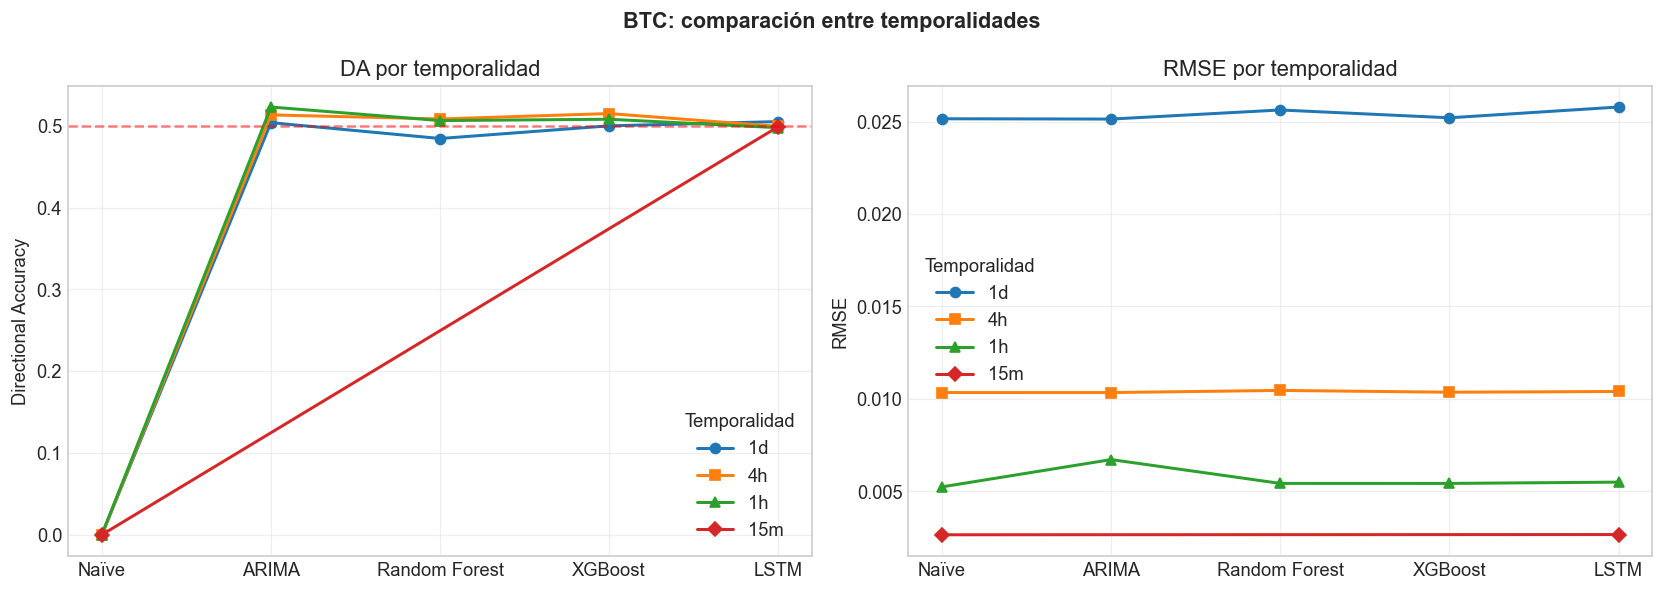

Figura guardada: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Figuras\btc_temporalidades_comparacion.png


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_plot = ['Naïve', 'ARIMA', 'Random Forest',
                'XGBoost', 'LSTM']
markers = {'1d':'o', '4h':'s', '1h':'^', '15m':'D'}

for tf, marker in markers.items():
    subset = btc_all[btc_all['Timeframe'] == tf]
    for metric, ax in [('DA', axes[0]), ('RMSE', axes[1])]:
        values, labels = [], []
        for m in models_plot:
            row = subset[subset['Model'] == m]
            if len(row) > 0:
                values.append(row[metric].values[0])
                labels.append(m)
        ax.plot(labels, values, marker=marker,
                label=tf, linewidth=1.8)

axes[0].set_ylabel('Directional Accuracy')
axes[0].set_title('DA por temporalidad')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[0].legend(title='Temporalidad')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE por temporalidad')
axes[1].legend(title='Temporalidad')

plt.suptitle('BTC: comparación entre temporalidades',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig_path = FIGURES_DIR / 'btc_temporalidades_comparacion.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {fig_path}')

### 3.6 Test de Diebold-Mariano por temporalidad

Aplicacion del test DM a los pares de modelos disponibles en cada
temporalidad (cinco modelos en 4h y 1h; solo Naive y LSTM en 15m).

In [53]:
if DM_AVAILABLE:
    print("Test DM para BTC por temporalidad\n")
    dm_btc_rows = []
    for tf_name, ds in BTC_TF.items():
        print(f"{'='*50}")
        print(f"  {tf_name}")
        print(f"{'='*50}")
        y_true = ds['y_test'].values
        model_preds = {}
        for mn in models_plot:
            key = (tf_name, mn)
            if key in all_preds_btc:
                p = all_preds_btc[key]
                if len(p) == len(y_true):
                    model_preds[mn] = p
        for m1, m2 in itertools.combinations(
                list(model_preds.keys()), 2):
            try:
                stat, pval = dm_test(
                    y_true, model_preds[m1],
                    model_preds[m2], h=1)
                stars = ('***' if pval < 0.001
                         else '**' if pval < 0.01
                         else '*' if pval < 0.05 else '')
                winner = m1 if stat < 0 else m2
                print(f"  {m1:<15} vs {m2:<15} | "
                      f"DM={stat:+.3f} p={pval:.4f} "
                      f"{stars:<3} -> {winner}")
                dm_btc_rows.append({
                    'Timeframe': tf_name,
                    'Model1': m1, 'Model2': m2,
                    'DM_stat': stat, 'p_value': pval,
                    'Winner': winner})
            except Exception as e:
                print(f"  {m1} vs {m2}: error ({e})")
        print()

    if dm_btc_rows:
        pd.DataFrame(dm_btc_rows).to_csv(
            RESULTS_DIR / 'btc_dm_tf.csv', index=False)
        print(f'Resultados DM BTC guardados: '
              f'{RESULTS_DIR / "btc_dm_tf.csv"}')

Test DM para BTC por temporalidad

  BTC_4h
  Naïve           vs ARIMA           | DM=+0.130 p=0.8963     -> ARIMA
  Naïve           vs Random Forest   | DM=-1.648 p=0.0995     -> Naïve
  Naïve           vs XGBoost         | DM=-1.817 p=0.0693     -> Naïve
  Naïve           vs LSTM            | DM=-1.821 p=0.0687     -> Naïve
  ARIMA           vs Random Forest   | DM=-1.659 p=0.0971     -> ARIMA
  ARIMA           vs XGBoost         | DM=-1.952 p=0.0510     -> ARIMA
  ARIMA           vs LSTM            | DM=-1.830 p=0.0673     -> ARIMA
  Random Forest   vs XGBoost         | DM=+1.403 p=0.1608     -> XGBoost
  Random Forest   vs LSTM            | DM=+0.837 p=0.4026     -> LSTM
  XGBoost         vs LSTM            | DM=-1.218 p=0.2232     -> XGBoost

  BTC_1h
  Naïve           vs ARIMA           | DM=-25.384 p=0.0000 *** -> Naïve
  Naïve           vs Random Forest   | DM=-1.085 p=0.2779     -> Naïve
  Naïve           vs XGBoost         | DM=-1.804 p=0.0713     -> Naïve
  Naïve           v

### 3.7 Exportacion y cierre

Guardado de las metricas y de los p-valores DM de BTC intraday en
`Resultados/`.

In [54]:
btc_all.to_csv(
    RESULTS_DIR / 'btc_metricas_por_tf.csv', index=False)
print(f'Métricas BTC por temporalidad guardadas: '
      f'{RESULTS_DIR / "btc_metricas_por_tf.csv"}')

print('\nNotebook ejecutado correctamente.')

Métricas BTC por temporalidad guardadas: C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Resultados\btc_metricas_por_tf.csv

Notebook ejecutado correctamente.


Los resultados de este bloque se discuten en la seccion 5.7 del TFG: la
DA se mantiene en el entorno del 50 % en las cuatro temporalidades
y ningun modelo extrae senal direccional sobre el baseline.